# Лабораторная работа №2
## Разведочный анализ данных (EDA)

**Выполнил:** _Машканов Михаил Вячеславович_
**Группа:** _14_

**Среда выполнения:** Anaconda Distribution, Jupyter Notebook, окружение conda `lab1_terminal`, ОС Windows 10 (x64).

**Цель работы:** изучение основных методов разведочного анализа данных, выявление скрытых
закономерностей, поиск аномалий, визуализация распределений признаков и подготовка данных
к последующему моделированию.

> Дополнительное задание (интерактивный дашборд на Streamlit) — скрипт [`app_streamlit.py`](app_streamlit.py),
> описание и порядок запуска приведены в конце блокнота.

---
# Часть 1. Наборы данных

По условию работы подобраны **два набора данных**, отличающихся от использованных в ЛР №1
(Iris и Titanic). Один набор — с преобладанием числовых признаков, второй — с большим числом
категориальных признаков и пропусками.

| № | Набор данных | Источник | Файл | Объектов | Признаков | Характер признаков |
|---|---|---|---|---|---|---|
| 1 | Wine Quality (красные вина) | [UCI ML Repository](https://archive.ics.uci.edu/dataset/186/wine+quality) | `data/winequality-red.csv` | 1599 | 12 | все числовые (11 физико-химических показателей + оценка качества) |
| 2 | Adult (Census Income) | [UCI ML Repository](https://archive.ics.uci.edu/dataset/2/adult) | `data/adult.csv` | 32561 | 15 | 6 числовых, 9 категориальных; пропуски закодированы символом `?` |

Оба файла скачаны с UCI без изменений, поэтому все особенности «сырых» данных
(разделитель `;`, отсутствие строки заголовка, пробелы перед значениями, пропуски в виде `?`)
обрабатываются непосредственно в блокноте.

In [1]:
import os, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from IPython.display import display

%matplotlib inline

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 10
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:.3f}".format)

DATA_DIR = Path("data")

print("Окружение conda :", os.environ.get("CONDA_DEFAULT_ENV", Path(sys.prefix).name))
print("Python          :", sys.version.split()[0])
for lib in (np, pd, matplotlib, sns):
    print(f"{lib.__name__:<16}: {lib.__version__}")
print("Файлы данных    :", [p.name for p in sorted(DATA_DIR.glob("*.csv"))])

Окружение conda : lab1_terminal
Python          : 3.12.14
numpy           : 2.5.3
pandas          : 3.0.6
matplotlib      : 3.11.2
seaborn         : 0.13.2
Файлы данных    : ['adult.csv', 'winequality-red.csv']


Для поиска выбросов в обоих наборах используется одно и то же **правило межквартильного
размаха (IQR, правило Тьюки)** — то же правило, по которому `boxplot` рисует «усы»:
значение считается статистическим выбросом, если оно лежит вне интервала
$[Q_1 - 1.5\cdot IQR;\ Q_3 + 1.5\cdot IQR]$, где $IQR = Q_3 - Q_1$.
Для наглядного сравнения числовых признаков также вводится вспомогательная функция
сводной статистики.

In [2]:
def iqr_bounds(df: pd.DataFrame) -> tuple[pd.Series, pd.Series]:
    # Границы «усов» по правилу 1.5*IQR для каждого числового столбца
    num = df.select_dtypes("number")
    q1, q3 = num.quantile(0.25), num.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr


def outlier_mask(df: pd.DataFrame) -> pd.DataFrame:
    # True там, где значение — статистический выброс
    num = df.select_dtypes("number")
    low, high = iqr_bounds(num)
    return (num < low) | (num > high)


def iqr_outliers(df: pd.DataFrame) -> pd.DataFrame:
    # Число и доля выбросов по правилу 1.5*IQR для каждого числового столбца
    low, high = iqr_bounds(df)
    mask = outlier_mask(df)
    return pd.DataFrame({
        "нижняя граница": low, "верхняя граница": high,
        "выбросов": mask.sum(), "доля, %": (mask.mean() * 100).round(2),
    }).sort_values("выбросов", ascending=False)


def numeric_summary(df: pd.DataFrame) -> pd.DataFrame:
    # Описательные статистики числовых признаков, включая медиану и асимметрию
    num = df.select_dtypes("number")
    return pd.DataFrame({
        "среднее": num.mean(), "медиана": num.median(), "СКО": num.std(),
        "min": num.min(), "Q1 (25%)": num.quantile(0.25), "Q3 (75%)": num.quantile(0.75),
        "max": num.max(), "асимметрия": num.skew(),
    })


def top_correlations(corr: pd.DataFrame, n: int = 10) -> pd.Series:
    # Пары признаков с наибольшей по модулю корреляцией (без диагонали и повторов)
    upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
    pairs = upper.stack()
    return pairs.reindex(pairs.abs().sort_values(ascending=False).index).head(n)

---
# Часть 2.1. Набор данных №1 — Wine Quality (красные вина)

Результаты лабораторных физико-химических измерений 1599 образцов красного португальского
вина *Vinho Verde* и экспертная оценка его качества по шкале от 0 до 10 (медиана оценок
не менее трёх дегустаторов). Целевой признак — `quality`.

## 1. Первичный аудит и структура данных

In [3]:
wine_raw = pd.read_csv(DATA_DIR / "winequality-red.csv", sep=";")

# Имена столбцов содержат пробелы — приводим их к snake_case для удобства обращения
wine_raw.columns = wine_raw.columns.str.replace(" ", "_")

print("Первые 10 строк:")
display(wine_raw.head(10))
print("Последние 10 строк:")
display(wine_raw.tail(10))

Первые 10 строк:


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.400,0.700,0.000,1.900,0.076,11.000,34.000,0.998,3.510,0.560,9.400,5
1,7.800,0.880,0.000,2.600,0.098,25.000,67.000,0.997,3.200,0.680,9.800,5
2,7.800,0.760,0.040,2.300,0.092,15.000,54.000,0.997,3.260,0.650,9.800,5
3,11.200,0.280,0.560,1.900,0.075,17.000,60.000,0.998,3.160,0.580,9.800,6
4,7.400,0.700,0.000,1.900,0.076,11.000,34.000,0.998,3.510,0.560,9.400,5
5,7.400,0.660,0.000,1.800,0.075,13.000,40.000,0.998,3.510,0.560,9.400,5
6,7.900,0.600,0.060,1.600,0.069,15.000,59.000,0.996,3.300,0.460,9.400,5
7,7.300,0.650,0.000,1.200,0.065,15.000,21.000,0.995,3.390,0.470,10.000,7
8,7.800,0.580,0.020,2.000,0.073,9.000,18.000,0.997,3.360,0.570,9.500,7
9,7.500,0.500,0.360,6.100,0.071,17.000,102.000,0.998,3.350,0.800,10.500,5


Последние 10 строк:


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
1589,6.600,0.725,0.200,7.800,0.073,29.000,79.000,0.998,3.290,0.540,9.200,5
1590,6.300,0.550,0.150,1.800,0.077,26.000,35.000,0.993,3.320,0.820,11.600,6
1591,5.400,0.740,0.090,1.700,0.089,16.000,26.000,0.994,3.670,0.560,11.600,6
1592,6.300,0.510,0.130,2.300,0.076,29.000,40.000,0.996,3.420,0.750,11.000,6
1593,6.800,0.620,0.080,1.900,0.068,28.000,38.000,0.997,3.420,0.820,9.500,6
1594,6.200,0.600,0.080,2.000,0.090,32.000,44.000,0.995,3.450,0.580,10.500,5
1595,5.900,0.550,0.100,2.200,0.062,39.000,51.000,0.995,3.520,0.760,11.200,6
1596,6.300,0.510,0.130,2.300,0.076,29.000,40.000,0.996,3.420,0.750,11.000,6
1597,5.900,0.645,0.120,2.000,0.075,32.000,44.000,0.995,3.570,0.710,10.200,5
1598,6.000,0.310,0.470,3.600,0.067,18.000,42.000,0.995,3.390,0.660,11.000,6


In [4]:
n_rows, n_cols = wine_raw.shape
print(f"Размерность матрицы данных: {n_rows} строк × {n_cols} столбцов")
print()
wine_raw.info()

Размерность матрицы данных: 1599 строк × 12 столбцов

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         1599 non-null   float64
 1   volatile_acidity      1599 non-null   float64
 2   citric_acid           1599 non-null   float64
 3   residual_sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free_sulfur_dioxide   1599 non-null   float64
 6   total_sulfur_dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


Все 12 столбцов прочитаны как числовые, ненулевых значений в каждом столбце 1599 — столько же,
сколько строк. Проверим, соответствуют ли типы реальным значениям: столбцы типа `float64`
могут фактически содержать только целые числа (тогда признак дискретный), а целочисленный
столбец может оказаться категориальным.

In [5]:
type_check = pd.DataFrame({
    "тип pandas": wine_raw.dtypes.astype(str),
    "уникальных значений": wine_raw.nunique(),
    "все значения целые": wine_raw.apply(lambda s: bool((s % 1 == 0).all())),
    "min": wine_raw.min(),
    "max": wine_raw.max(),
})
type_check

,тип pandas,уникальных значений,все значения целые,min,max
fixed_acidity,float64,96,False,4.600,15.900
volatile_acidity,float64,143,False,0.120,1.580
citric_acid,float64,80,False,0.000,1.000
residual_sugar,float64,91,False,0.900,15.500
chlorides,float64,153,False,0.012,0.611
free_sulfur_dioxide,float64,60,False,1.000,72.000
total_sulfur_dioxide,float64,144,False,6.000,289.000
density,float64,436,False,0.990,1.004
pH,float64,89,False,2.740,4.010
sulphates,float64,96,False,0.330,2.000


**Интерпретация.** Типы соответствуют содержимому: 11 физико-химических показателей —
непрерывные вещественные величины. Два признака диоксида серы (`free_sulfur_dioxide`,
`total_sulfur_dioxide`) хранятся как `float64`, хотя почти все их значения целые: встречаются
лишь единичные дробные значения вида 5.5 или 77.5, поэтому вещественный тип оправдан и менять
его не требуется.
Целевой признак `quality` имеет тип `int64`, но принимает всего **6 значений (3…8)** — по смыслу
это **порядковая категориальная** переменная. Для графиков введём производный признак
`quality_label` с тремя уровнями качества.

## 2. Статистический анализ и очистка данных

### 2.1. Описательные статистики

In [6]:
numeric_summary(wine_raw)

,среднее,медиана,СКО,min,Q1 (25%),Q3 (75%),max,асимметрия
fixed_acidity,8.320,7.900,1.741,4.600,7.100,9.200,15.900,0.983
volatile_acidity,0.528,0.520,0.179,0.120,0.390,0.640,1.580,0.672
citric_acid,0.271,0.260,0.195,0.000,0.090,0.420,1.000,0.318
residual_sugar,2.539,2.200,1.410,0.900,1.900,2.600,15.500,4.541
chlorides,0.087,0.079,0.047,0.012,0.070,0.090,0.611,5.680
free_sulfur_dioxide,15.875,14.000,10.460,1.000,7.000,21.000,72.000,1.251
total_sulfur_dioxide,46.468,38.000,32.895,6.000,22.000,62.000,289.000,1.516
density,0.997,0.997,0.002,0.990,0.996,0.998,1.004,0.071
pH,3.311,3.310,0.154,2.740,3.210,3.400,4.010,0.194
sulphates,0.658,0.620,0.170,0.330,0.550,0.730,2.000,2.429


In [7]:
# Целевой признак как категориальный: число уникальных значений, мода, частоты
quality = wine_raw["quality"].astype("category")
print("Уникальных значений quality:", quality.nunique())
print("Мода quality               :", quality.mode().tolist())
print()
print(pd.DataFrame({"число образцов": quality.value_counts().sort_index(),
                    "доля, %": (quality.value_counts(normalize=True).sort_index() * 100).round(1)}))

Уникальных значений quality: 6
Мода quality               : [5]

         число образцов  доля, %
quality                         
3                    10    0.600
4                    53    3.300
5                   681   42.600
6                   638   39.900
7                   199   12.400
8                    18    1.100


**Интерпретация.**
* У большинства признаков среднее больше медианы, а коэффициент асимметрии положителен —
  распределения **скошены вправо** (длинный «хвост» больших значений). Сильнее всего это
  выражено у `chlorides` (асимметрия ≈ 5.7), `residual_sugar` (≈ 4.5) и `sulphates` (≈ 2.4):
  максимум у них в несколько раз превышает третий квартиль — признак наличия выбросов.
* Признаки измерены в **разных масштабах**: `density` меняется в третьем знаке после запятой
  (СКО ≈ 0.002), а `total_sulfur_dioxide` — в десятках единиц (СКО ≈ 33). Перед обучением
  моделей, чувствительных к масштабу, потребуется стандартизация.
* Классы целевого признака **сильно несбалансированы**: оценки 5 и 6 составляют ≈ 82 %
  выборки, а крайние оценки 3 и 8 — всего 10 и 18 образцов. Мода — 5.

In [8]:
print("Пропущенные значения (NaN) по столбцам:")
print(wine_raw.isna().sum().to_string())
print("\nВсего пропусков:", int(wine_raw.isna().sum().sum()))

Пропущенные значения (NaN) по столбцам:
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0

Всего пропусков: 0


### 2.2. Пропущенные значения

Пропусков в наборе **нет** ни в одном столбце, поэтому обработка не требуется.
Способы обработки пропусков продемонстрированы на втором наборе данных (Adult),
где они действительно присутствуют.

### 2.3. Дубликаты

In [9]:
dup_mask = wine_raw.duplicated(keep=False)
n_dups = wine_raw.duplicated().sum()
print(f"Полностью повторяющихся строк (лишних копий): {n_dups} ({n_dups / len(wine_raw):.1%})")
print(f"Строк, входящих в группы дубликатов         : {dup_mask.sum()}")
print("\nПример группы одинаковых строк:")
display(wine_raw[dup_mask].sort_values(list(wine_raw.columns)).head(4))

wine = wine_raw.drop_duplicates().reset_index(drop=True)
print(f"Размерность до удаления дубликатов   : {wine_raw.shape}")
print(f"Размерность после удаления дубликатов: {wine.shape}")

Полностью повторяющихся строк (лишних копий): 240 (15.0%)
Строк, входящих в группы дубликатов         : 460

Пример группы одинаковых строк:


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
142,5.200,0.340,0.000,1.800,0.050,27.000,63.000,0.992,3.680,0.790,14.000,6
144,5.200,0.340,0.000,1.800,0.050,27.000,63.000,0.992,3.680,0.790,14.000,6
131,5.600,0.500,0.090,2.300,0.049,17.000,99.000,0.994,3.630,0.630,13.000,5
132,5.600,0.500,0.090,2.300,0.049,17.000,99.000,0.994,3.630,0.630,13.000,5


Размерность до удаления дубликатов   : (1599, 12)
Размерность после удаления дубликатов: (1359, 12)


**Интерпретация.** Обнаружено **240 строк-дубликатов** (15 % выборки), совпадающих
по всем 12 признакам, включая значения, измеренные с точностью до четырёх знаков
(`density`). Случайное совпадение такого набора измерений практически невозможно,
поэтому это повторно внесённые в таблицу образцы. Они удалены: дальнейший анализ выполняется
на **1359 уникальных** образцах. Иначе повторы искусственно усиливали бы вес части наблюдений
и искажали частоты и корреляции.

In [10]:
# Производный категориальный признак для графиков: уровень качества
wine["quality_label"] = pd.cut(wine["quality"], bins=[0, 4, 6, 10],
                               labels=["низкое (3–4)", "среднее (5–6)", "высокое (7–8)"])
WINE_FEATURES = [c for c in wine.columns if c not in ("quality", "quality_label")]
# Единые цвета уровней качества для всех графиков
WINE_PALETTE = dict(zip(wine["quality_label"].cat.categories, sns.color_palette("Set2", 3)))
wine["quality_label"].value_counts().sort_index()

quality_label
низкое (3–4)       63
среднее (5–6)    1112
высокое (7–8)     184
Name: count, dtype: int64

## 3. Визуальный анализ распределений и поиск аномалий

### 3.1. Распределение целевого признака

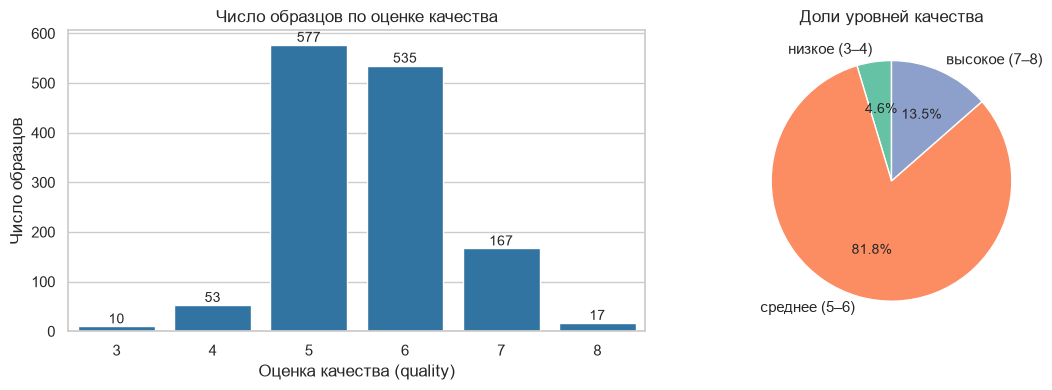

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=wine, x="quality", color="tab:blue", ax=axes[0])
axes[0].bar_label(axes[0].containers[0])
axes[0].set_title("Число образцов по оценке качества")
axes[0].set_xlabel("Оценка качества (quality)")
axes[0].set_ylabel("Число образцов")

wine["quality_label"].value_counts().sort_index().plot.pie(
    autopct="%1.1f%%", startangle=90, ax=axes[1], colors=list(WINE_PALETTE.values()))
axes[1].set_ylabel("")
axes[1].set_title("Доли уровней качества")

fig.tight_layout()
plt.show()

**Интерпретация.** Распределение оценок близко к нормальному с центром между 5 и 6,
но **крайние классы почти пусты**. Более 80 % вин имеют среднее качество; вина низкого
качества составляют менее 5 %. При постановке задачи классификации понадобятся меры против
дисбаланса классов (укрупнение классов, взвешивание, стратифицированное разбиение).

### 3.2. Гистограммы и графики плотности всех признаков

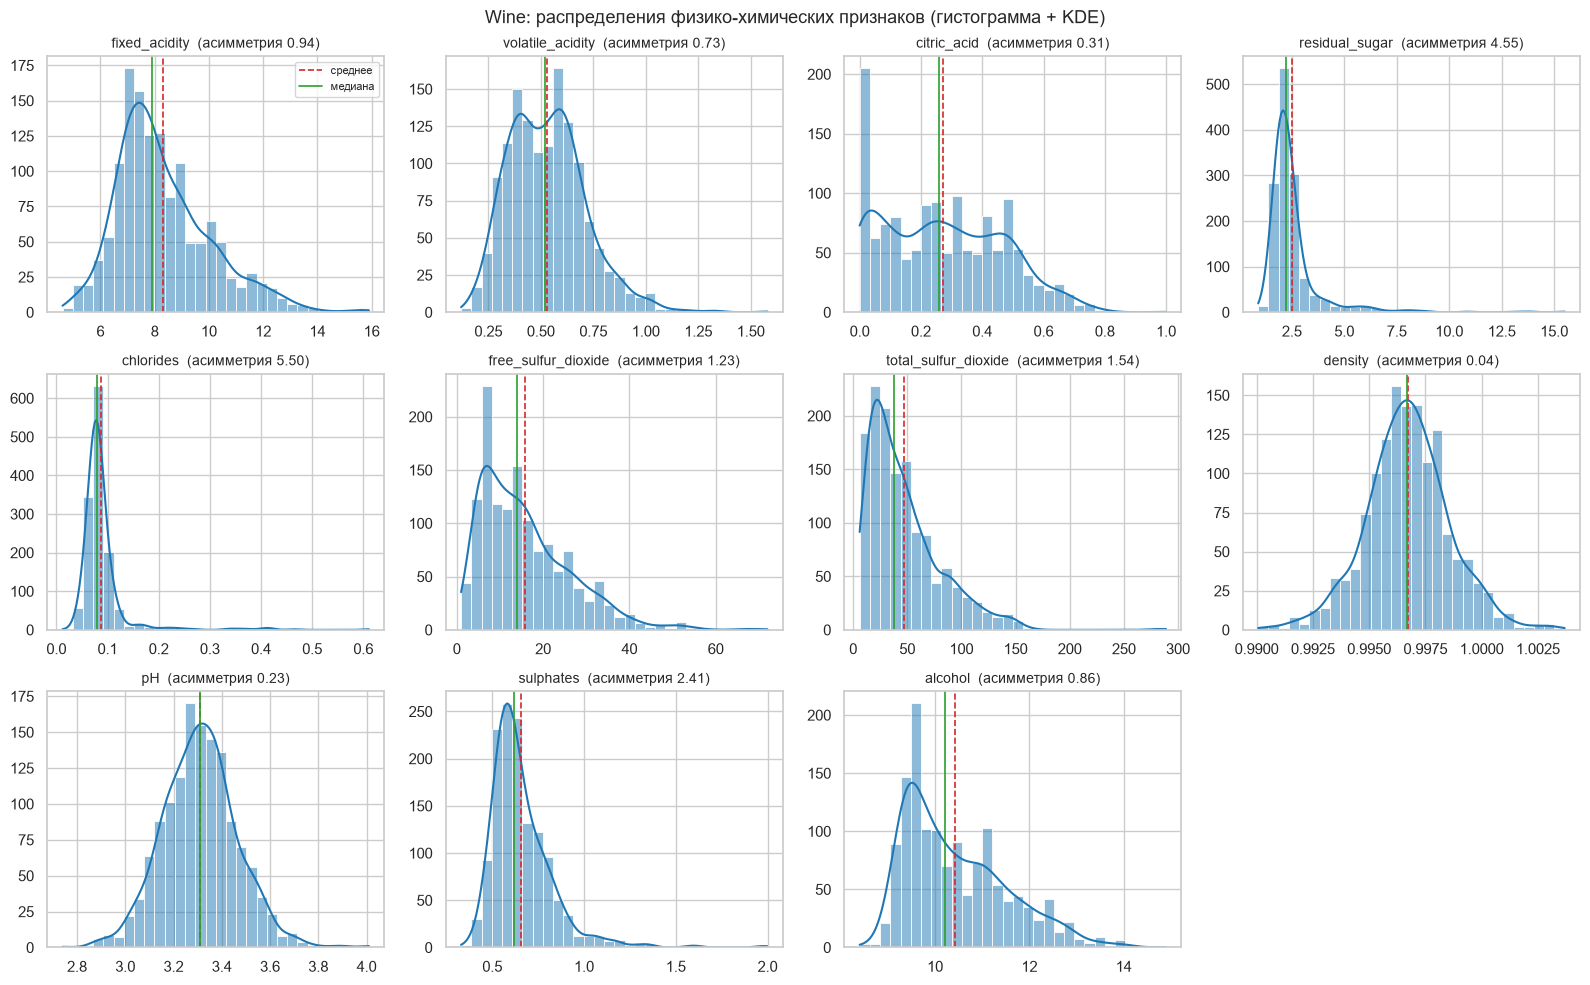

In [12]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

for ax, col in zip(axes.flat, WINE_FEATURES):
    sns.histplot(data=wine, x=col, bins=30, kde=True, color="tab:blue", ax=ax)
    ax.axvline(wine[col].mean(), color="tab:red", ls="--", lw=1.2, label="среднее")
    ax.axvline(wine[col].median(), color="tab:green", ls="-", lw=1.2, label="медиана")
    ax.set_title(f"{col}  (асимметрия {wine[col].skew():.2f})", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")

axes.flat[-1].axis("off")
axes.flat[0].legend(fontsize=8)
fig.suptitle("Wine: распределения физико-химических признаков (гистограмма + KDE)", fontsize=13)
fig.tight_layout()
plt.show()

**Интерпретация.**
* Близки к **симметричным, колоколообразным** распределения `density` и `pH` — у них среднее
  и медиана практически совпадают.
* Умеренно скошены вправо `fixed_acidity`, `volatile_acidity`, `alcohol`, `free_sulfur_dioxide`,
  `total_sulfur_dioxide`.
* У `residual_sugar`, `chlorides` и `sulphates` основная масса значений сосредоточена в узком
  диапазоне, а справа тянется **длинный редкий хвост** — это и есть потенциальные аномалии.
* `citric_acid` имеет необычную форму: заметный пик в нуле (вина без лимонной кислоты)
  и дополнительные пики около 0.25 и 0.5 — распределение многомодальное.

### 3.3. Один признак — разные типы графиков

Сравним распределение содержания алкоголя (`alcohol`) в группах качества тремя способами:
гистограммой (`histplot`), графиком плотности (`kdeplot`) и скрипичной диаграммой
(`violinplot`), а также дополнительно эмпирической функцией распределения (`ecdfplot`).

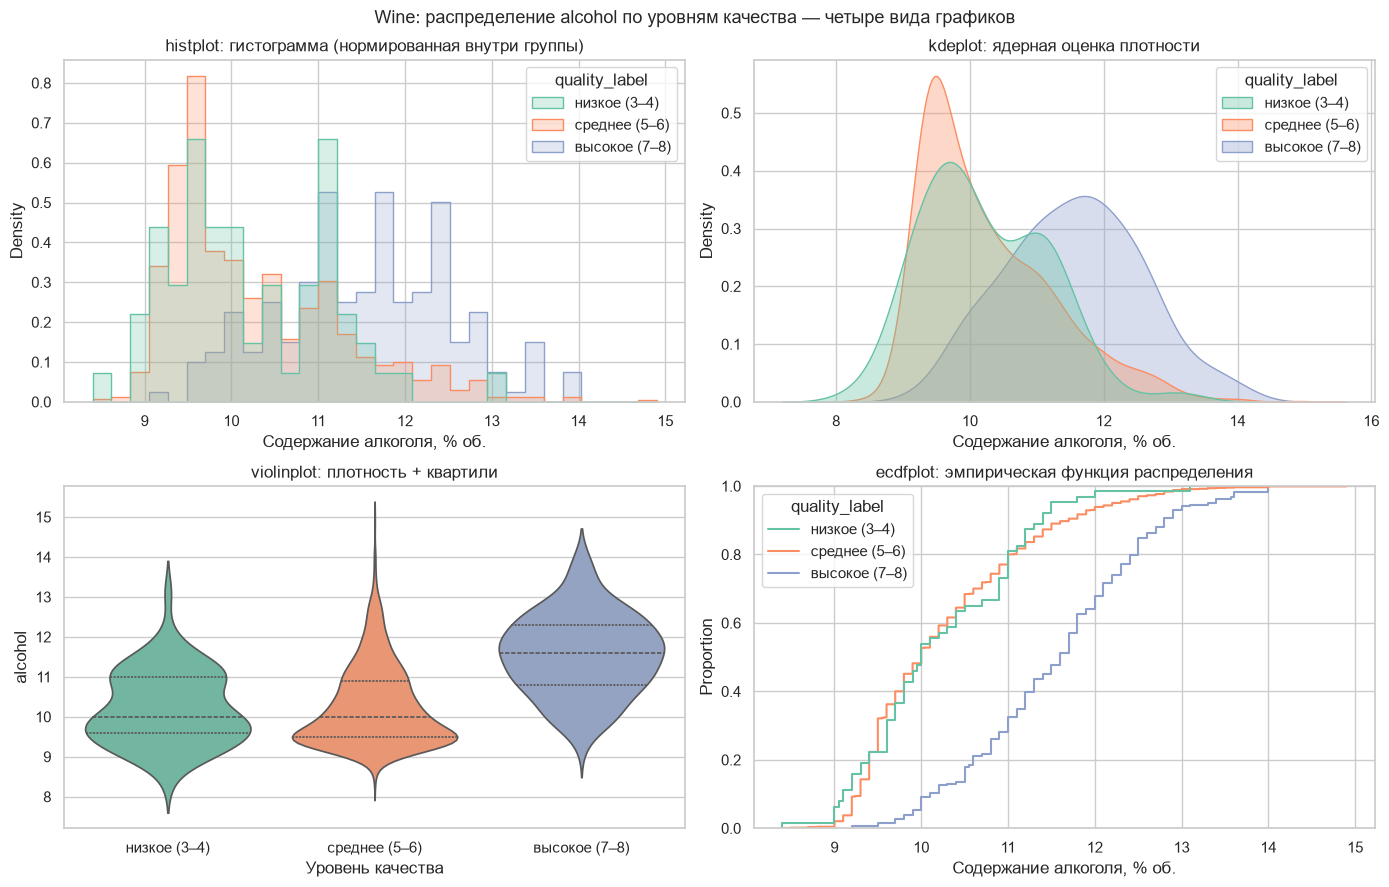

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
pal = WINE_PALETTE

sns.histplot(data=wine, x="alcohol", hue="quality_label", bins=30, stat="density",
             common_norm=False, element="step", palette=pal, ax=axes[0, 0])
axes[0, 0].set_title("histplot: гистограмма (нормированная внутри группы)")

sns.kdeplot(data=wine, x="alcohol", hue="quality_label", fill=True, common_norm=False,
            alpha=0.35, palette=pal, ax=axes[0, 1])
axes[0, 1].set_title("kdeplot: ядерная оценка плотности")

# Для violinplot уровни передаются строками: при категориальном hue seaborn 0.13
# в связке с pandas 3 сопоставляет цвета уровням в неверном порядке
sns.violinplot(data=wine.assign(quality_label=wine["quality_label"].astype(str)),
               x="quality_label", y="alcohol", hue="quality_label", order=list(pal),
               inner="quartile", palette=pal, legend=False, ax=axes[1, 0])
axes[1, 0].set_title("violinplot: плотность + квартили")
axes[1, 0].set_xlabel("Уровень качества")

sns.ecdfplot(data=wine, x="alcohol", hue="quality_label", palette=pal, ax=axes[1, 1])
axes[1, 1].set_title("ecdfplot: эмпирическая функция распределения")

for ax in (axes[0, 0], axes[0, 1], axes[1, 1]):
    ax.set_xlabel("Содержание алкоголя, % об.")
fig.suptitle("Wine: распределение alcohol по уровням качества — четыре вида графиков", fontsize=13)
fig.tight_layout()
plt.show()

**Интерпретация и сравнение типов графиков.** Все четыре графика показывают одну и ту же
закономерность: **чем выше качество, тем выше содержание алкоголя** — распределение группы
«высокое» смещено вправо примерно на 1.5 % об. относительно группы «среднее».
При этом графики решают задачу по-разному:
* `histplot` честно показывает «сырые» данные, но его вид зависит от числа интервалов,
  а малочисленные группы выглядят зашумлёнными;
* `kdeplot` даёт гладкую кривую, по которой удобно сравнивать положение и форму
  распределений, но сглаживание может скрыть мелкие детали и «размазать» плотность за пределы
  реальных значений;
* `violinplot` объединяет плотность и квартили (пунктир — медиана и Q1/Q3) и компактно
  сравнивает несколько групп рядом;
* `ecdfplot` не требует выбора параметров сглаживания и позволяет прямо считывать квантили:
  например, около 87 % вин среднего качества имеют крепость ниже 11.5 %, а среди вин
  высокого качества — менее половины.

### 3.4. Диаграммы размаха (boxplot) и поиск выбросов

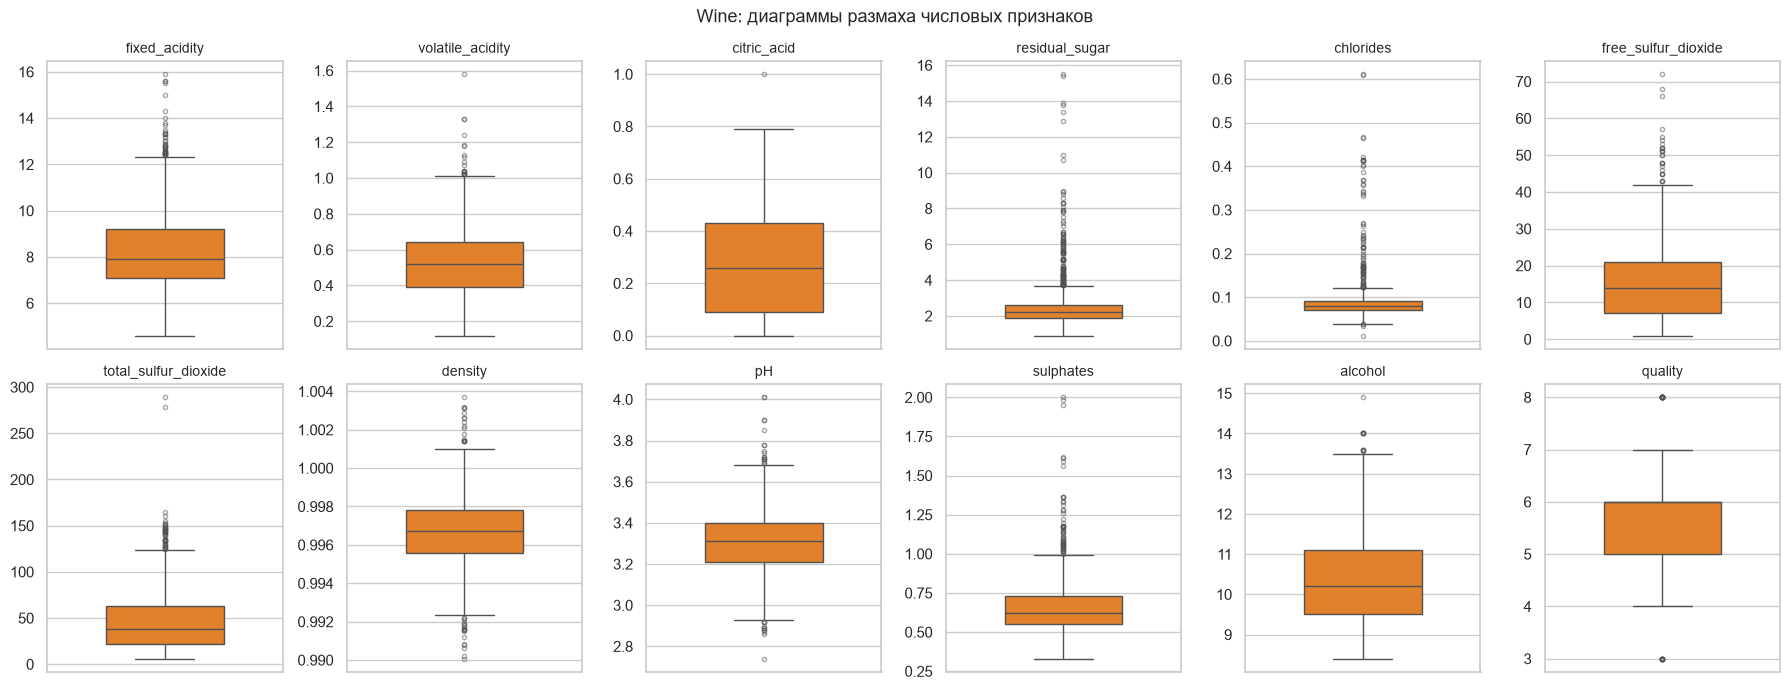

In [14]:
fig, axes = plt.subplots(2, 6, figsize=(18, 7))

for ax, col in zip(axes.flat, WINE_FEATURES + ["quality"]):
    sns.boxplot(y=wine[col], color="tab:orange", width=0.5,
                flierprops={"marker": "o", "markersize": 3, "alpha": 0.5}, ax=ax)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("")

fig.suptitle("Wine: диаграммы размаха числовых признаков", fontsize=13)
fig.tight_layout()
plt.show()

In [15]:
rows_with_outliers = outlier_mask(wine[WINE_FEATURES]).any(axis=1)
print(f"Строк, содержащих хотя бы один выброс: {rows_with_outliers.sum()} из {len(wine)} "
      f"({rows_with_outliers.mean():.1%})")
iqr_outliers(wine[WINE_FEATURES])

Строк, содержащих хотя бы один выброс: 340 из 1359 (25.0%)


,нижняя граница,верхняя граница,выбросов,"доля, %"
residual_sugar,0.850,3.650,126,9.270
chlorides,0.039,0.122,87,6.400
sulphates,0.280,1.000,55,4.050
total_sulfur_dioxide,-39.500,124.500,45,3.310
fixed_acidity,3.950,12.350,41,3.020
density,0.992,1.001,35,2.580
pH,2.925,3.685,28,2.060
free_sulfur_dioxide,-14.000,42.000,26,1.910
volatile_acidity,0.015,1.015,19,1.400
alcohol,7.100,13.500,12,0.880


**Интерпретация.**
* Больше всего выбросов у `residual_sugar` (≈ 9 % значений) и `chlorides` (≈ 6 %) — у них
  узкий межквартильный размах и длинный правый хвост. Выбросы почти исключительно
  **верхние**: отдельные вина содержат до 7 раз больше сахара и хлоридов, чем медианное вино.
* Для `sulphates`, `total_sulfur_dioxide` и `fixed_acidity` выбросов меньше, но встречаются
  экстремальные значения (например, `total_sulfur_dioxide` до 289 мг/дм³ при медиане 38).
* У `citric_acid` выброс единственный, у `alcohol` — единицы: эти признаки ограничены
  естественным диапазоном.
* Хотя по отдельности доля выбросов невелика, около четверти образцов содержат выброс хотя бы
  по одному признаку. Это не ошибки ввода, а **реальные, но редкие вина**, поэтому удалять их
  целиком нецелесообразно. Для моделирования разумнее ослабить их влияние
  логарифмированием или устойчивым масштабированием.

Проверим, как логарифмирование меняет распределения самых скошенных признаков:

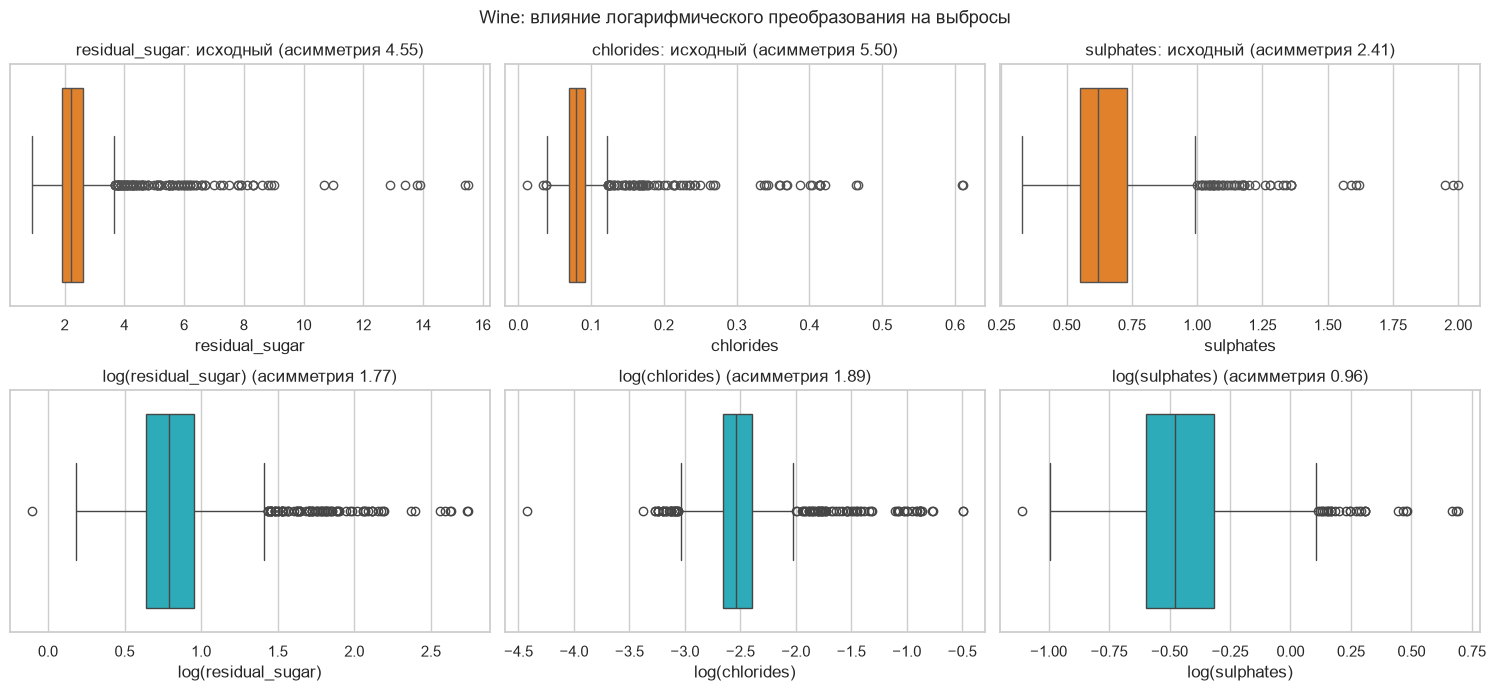

In [16]:
skewed = ["residual_sugar", "chlorides", "sulphates"]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))

for j, col in enumerate(skewed):
    sns.boxplot(x=wine[col], color="tab:orange", ax=axes[0, j])
    axes[0, j].set_title(f"{col}: исходный (асимметрия {wine[col].skew():.2f})")
    logged = np.log(wine[col])
    sns.boxplot(x=logged, color="tab:cyan", ax=axes[1, j])
    axes[1, j].set_title(f"log({col}) (асимметрия {logged.skew():.2f})")
    axes[1, j].set_xlabel(f"log({col})")

fig.suptitle("Wine: влияние логарифмического преобразования на выбросы", fontsize=13)
fig.tight_layout()
plt.show()

**Интерпретация.** После логарифмирования асимметрия снижается в 2.5–3 раза
(`residual_sugar`: 4.5 → 1.8, `chlorides`: 5.5 → 1.9, `sulphates`: 2.4 → 1.0),
а «хвост» выбросов заметно сжимается и становится симметричнее. Для этих признаков логарифм — подходящее преобразование
перед моделированием.

## 4. Корреляционный анализ и зависимости

### 4.1. Матрица корреляции Пирсона

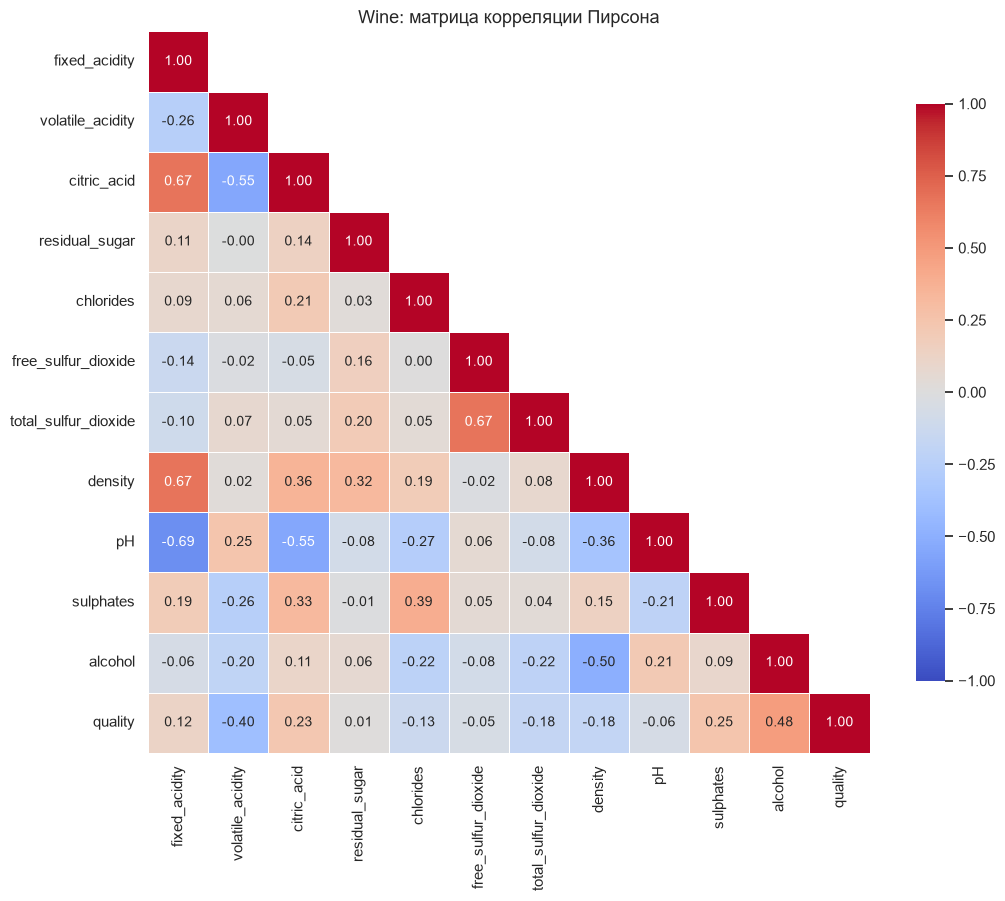

In [17]:
wine_corr = wine[WINE_FEATURES + ["quality"]].corr(method="pearson")

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(wine_corr, dtype=bool), k=1)
sns.heatmap(wine_corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Wine: матрица корреляции Пирсона", fontsize=13)
ax.grid(False)
fig.tight_layout()
plt.show()

In [18]:
wine_top = top_correlations(wine_corr, n=10)
wine_top.rename("r Пирсона").to_frame()

r Пирсона
fixed_acidity       pH                       -0.687
                    density                   0.670
                    citric_acid               0.667
free_sulfur_dioxide total_sulfur_dioxide      0.667
volatile_acidity    citric_acid              -0.551
citric_acid         pH                       -0.550
density             alcohol                  -0.505
alcohol             quality                   0.480
volatile_acidity    quality                  -0.395
chlorides           sulphates                 0.395

**Интерпретация тепловой карты.**
* Сильных (|r| > 0.7) зависимостей нет, но есть группа **заметных (|r| ≈ 0.55–0.69)**
  связей, отражающих химию вина:
  * `fixed_acidity` ↔ `pH` (r ≈ −0.69) — чем больше кислот, тем ниже pH (ожидаемая обратная связь);
  * `fixed_acidity` ↔ `citric_acid` и `fixed_acidity` ↔ `density` (r ≈ +0.67) — лимонная кислота входит
    в состав фиксированной кислотности, растворённые кислоты увеличивают плотность;
  * `free_sulfur_dioxide` ↔ `total_sulfur_dioxide` (r ≈ +0.67) — свободный диоксид серы является
    частью общего;
  * `volatile_acidity` ↔ `citric_acid` (r ≈ −0.55).
* С целевым признаком `quality` сильнее всего связаны `alcohol` (r ≈ +0.48) и
  `volatile_acidity` (r ≈ −0.40, летучие кислоты дают уксусный привкус).
  Остальные признаки связаны с качеством слабо.
* Высокая взаимная корреляция кислотных признаков означает частичную **мультиколлинеарность**
  — её стоит учитывать при построении линейных моделей.

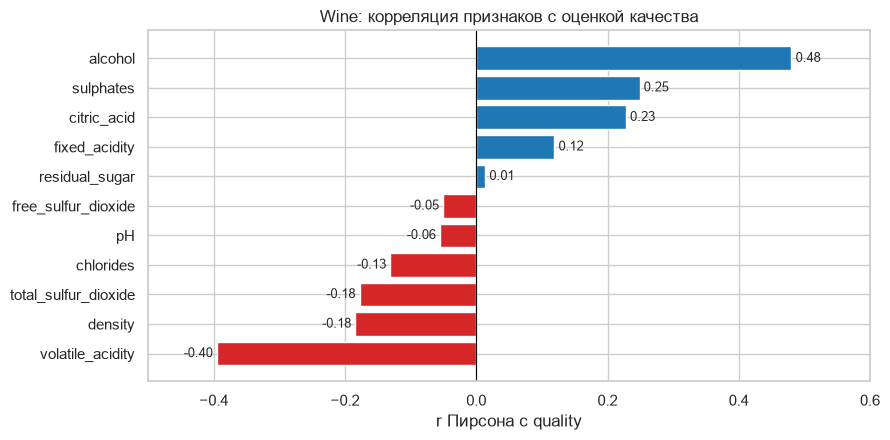

In [19]:
fig, ax = plt.subplots(figsize=(9, 4.5))
target_corr = wine_corr["quality"].drop("quality").sort_values()
colors = ["tab:red" if v < 0 else "tab:blue" for v in target_corr]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.bar_label(ax.containers[0], fmt="%.2f", padding=3, fontsize=9)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlim(-0.5, 0.6)
ax.set_title("Wine: корреляция признаков с оценкой качества")
ax.set_xlabel("r Пирсона с quality")
fig.tight_layout()
plt.show()

**Интерпретация.** Ранжирование подтверждает: наиболее информативные для предсказания
качества признаки — `alcohol`, `volatile_acidity`, `sulphates` и `citric_acid`.
Признаки `residual_sugar`, `free_sulfur_dioxide` и `pH` с качеством практически не связаны
линейно (|r| < 0.06).

### 4.2. Диаграммы рассеяния для пар с наиболее сильной зависимостью

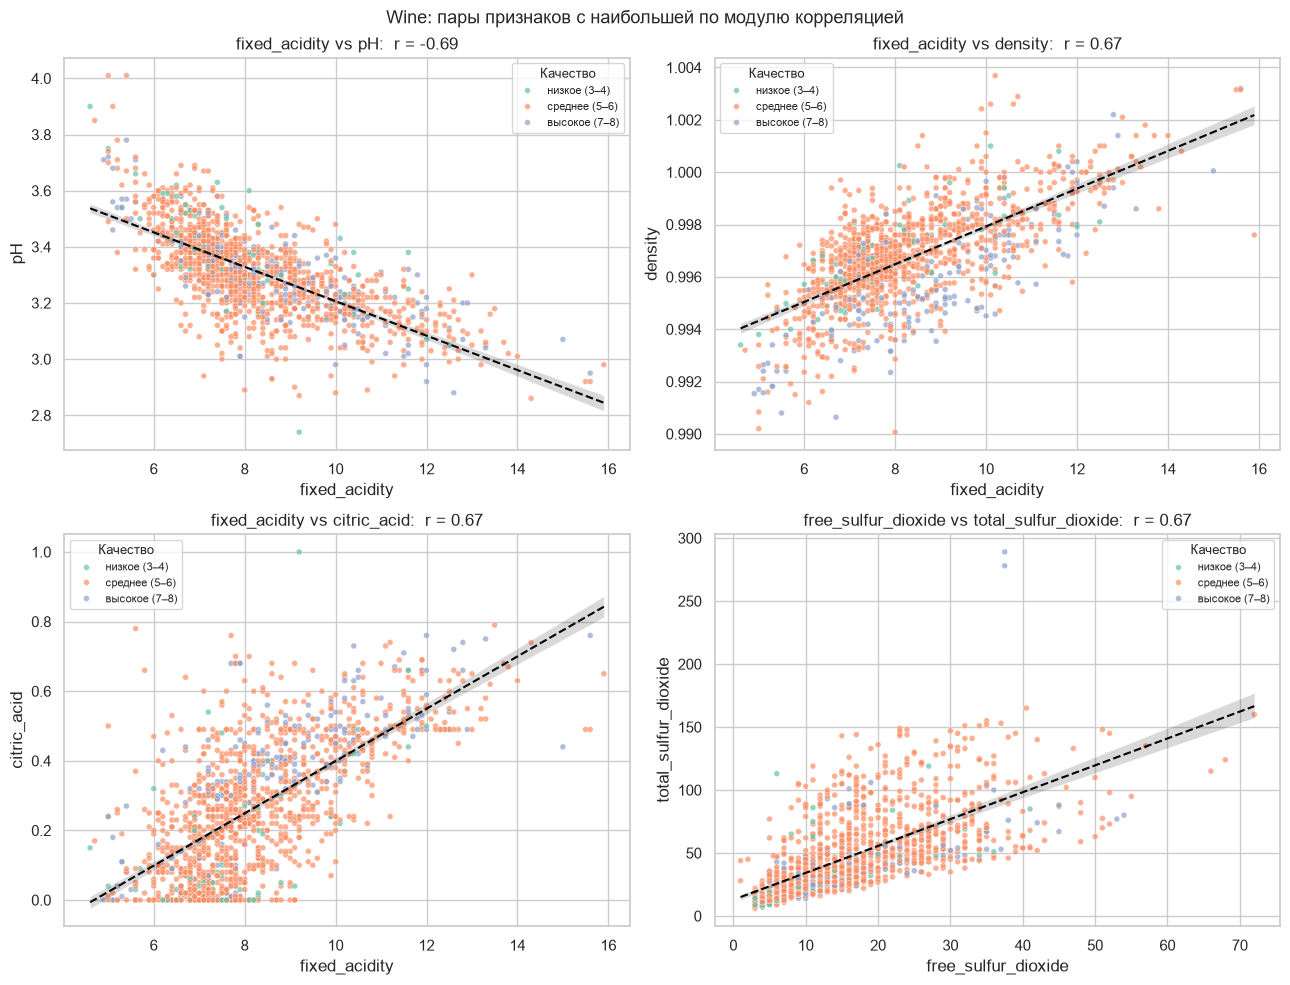

In [20]:
pairs = list(wine_top.index[:4])
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, (x, y) in zip(axes.flat, pairs):
    sns.scatterplot(data=wine, x=x, y=y, hue="quality_label", palette=WINE_PALETTE,
                    s=18, alpha=0.7, ax=ax)
    sns.regplot(data=wine, x=x, y=y, scatter=False, color="black",
                line_kws={"lw": 1.5, "ls": "--"}, ax=ax)
    ax.set_title(f"{x} vs {y}:  r = {wine_corr.loc[x, y]:.2f}")
    ax.legend(title="Качество", fontsize=8, title_fontsize=9)

fig.suptitle("Wine: пары признаков с наибольшей по модулю корреляцией", fontsize=13)
fig.tight_layout()
plt.show()

**Интерпретация.** На всех четырёх графиках облако точек вытянуто вдоль линии регрессии,
что подтверждает **линейный характер** связи. Разброс вокруг линии значителен, то есть зависимость
умеренная, а не функциональная. Цвета (уровни качества) по облакам перемешаны: эти пары
признаков описывают химический состав вина, но качество по ним не разделяется.

### 4.3. Парные графики (pairplot) для ключевых признаков

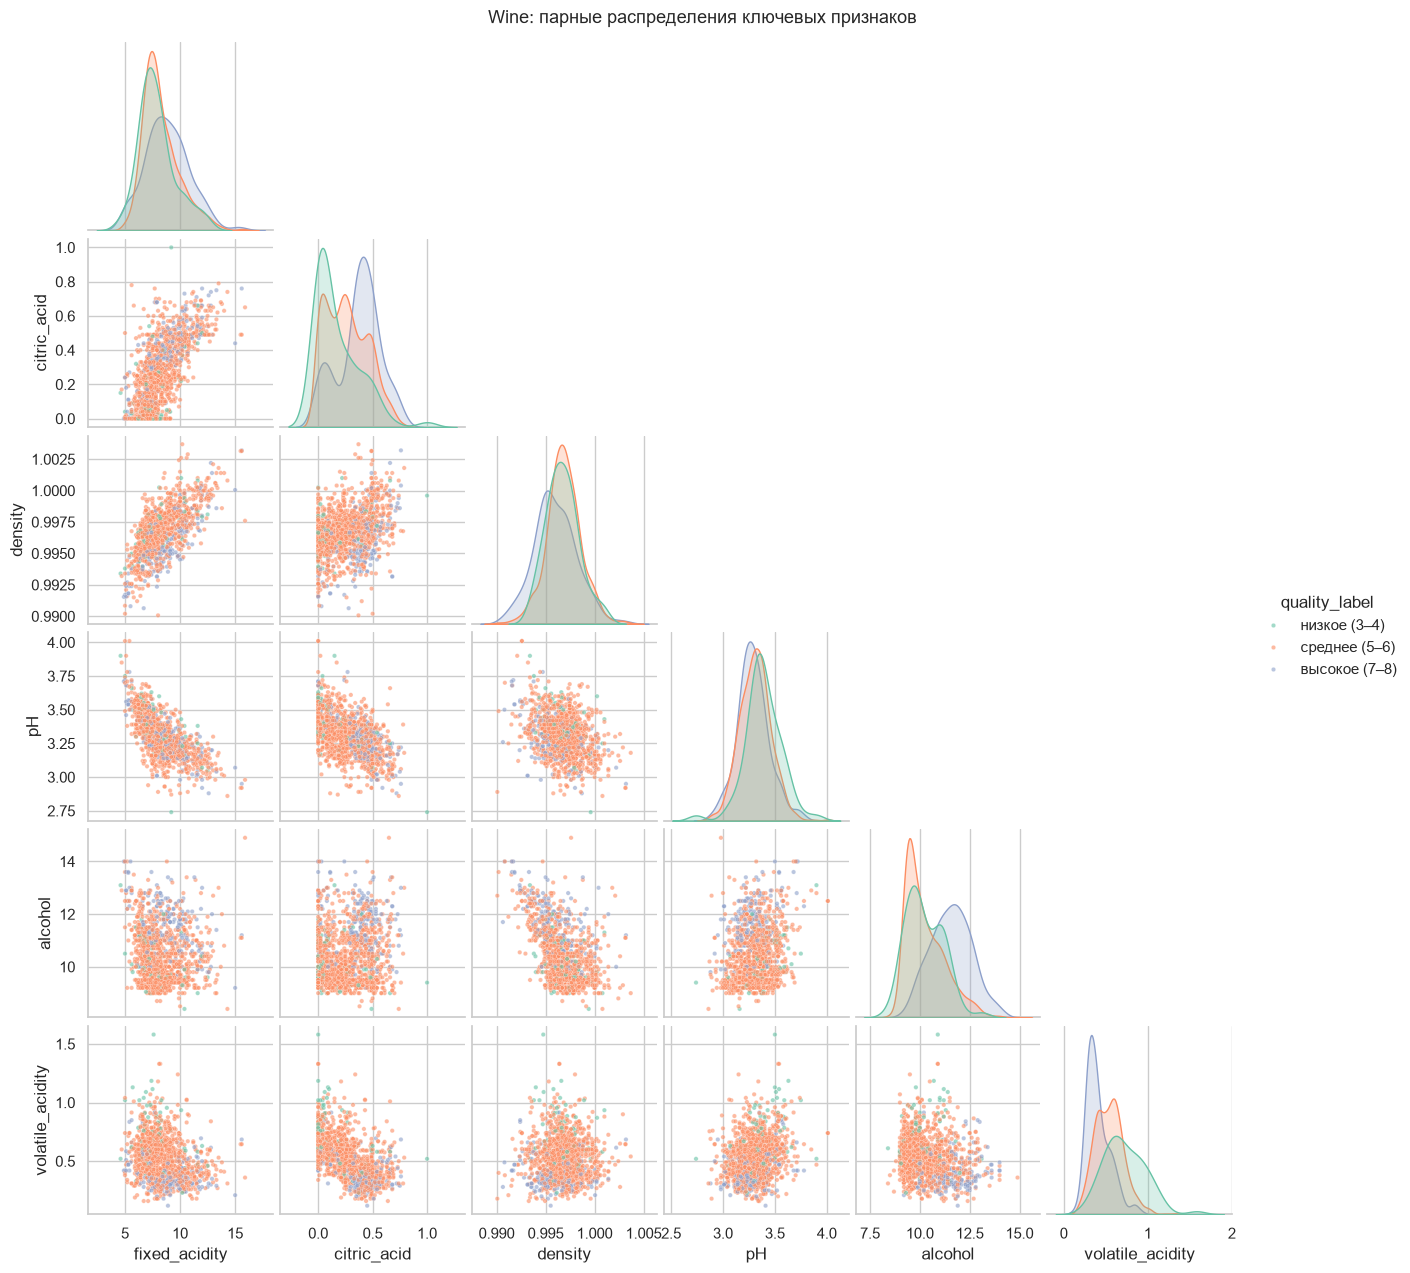

In [21]:
key_cols = ["fixed_acidity", "citric_acid", "density", "pH", "alcohol", "volatile_acidity"]
g = sns.pairplot(wine, vars=key_cols, hue="quality_label", palette=WINE_PALETTE,
                 corner=True, diag_kind="kde", height=2.1, diag_kws={"common_norm": False},
                 plot_kws={"s": 10, "alpha": 0.6})
g.figure.suptitle("Wine: парные распределения ключевых признаков", y=1.01, fontsize=13)
plt.show()

**Интерпретация.** Парный график объединяет распределения (на диагонали, нормированы внутри
каждой группы) и попарные зависимости. Хорошо видны треугольник связей `fixed_acidity`–`citric_acid`–`pH`
и связь `density`–`alcohol` (r ≈ −0.50: спирт легче воды, поэтому крепкие вина менее плотные).
На диагональных KDE группа «высокое» отчётливо смещена вправо по `alcohol` и влево по
`volatile_acidity` — эти два признака лучше всего разделяют уровни качества.

## Вывод по набору Wine Quality

* **Структура:** 1599 строк × 12 числовых столбцов, типы корректны; целевой признак `quality`
  дискретный порядковый (3…8) с сильным **дисбалансом классов** (≈ 82 % — оценки 5 и 6).
* **Очистка:** пропусков нет; найдено и удалено **240 дубликатов** (15 %), итоговый объём —
  1359 образцов.
* **Аномалии:** большинство признаков скошены вправо; больше всего выбросов у `residual_sugar`
  (≈ 9 %) и `chlorides` (≈ 6 %), четверть образцов содержит выброс хотя бы по одному
  признаку. Выбросы правдоподобны физически, поэтому для них рекомендуется логарифмирование,
  а не удаление.
* **Корреляции:** сильных (|r| > 0.7) связей нет; заметные связи образуют группу кислотных
  признаков (`fixed_acidity`, `citric_acid`, `pH`, `density`) и пару показателей диоксида серы.
  С качеством сильнее всего связаны `alcohol` (+0.48) и `volatile_acidity` (−0.40).

---
# Часть 2.2. Набор данных №2 — Adult (Census Income)

Выборка из переписи населения США 1994 года. Для каждого человека указаны демографические
и социальные характеристики (возраст, образование, семейное положение, профессия, раса, пол,
страна рождения и др.). Целевой признак `income` — превышает ли годовой доход $50 000.

## 1. Первичный аудит и структура данных

Файл не содержит строки заголовка, поэтому имена столбцов задаются вручную по описанию
набора на UCI. Сначала прочитаем файл «как есть», без дополнительных параметров.

In [22]:
ADULT_COLUMNS = [
    "age", "workclass", "fnlwgt", "education", "education_num", "marital_status",
    "occupation", "relationship", "race", "sex", "capital_gain", "capital_loss",
    "hours_per_week", "native_country", "income",
]

adult_naive = pd.read_csv(DATA_DIR / "adult.csv", header=None, names=ADULT_COLUMNS)

print("Значения столбца workclass в «сыром» виде:")
print([repr(v) for v in adult_naive["workclass"].unique()])
print("\nЯвных NaN после чтения:", int(adult_naive.isna().sum().sum()))

Значения столбца workclass в «сыром» виде:
["' State-gov'", "' Self-emp-not-inc'", "' Private'", "' Federal-gov'", "' Local-gov'", "' ?'", "' Self-emp-inc'", "' Without-pay'", "' Never-worked'"]

Явных NaN после чтения: 0


**Проверка соответствия значений.** При наивном чтении обнаруживаются две проблемы:
1. все текстовые значения начинаются с **пробела** (`' State-gov'`): разделитель в файле — `", "`;
2. пропуски закодированы не пустой ячейкой, а символом **`'?'`**, поэтому `pandas` считает
   данные полными (0 NaN), хотя это не так.

Исправим чтение: `skipinitialspace=True` убирает ведущие пробелы, `na_values="?"` превращает
`?` в настоящие пропуски.

In [23]:
adult_raw = pd.read_csv(DATA_DIR / "adult.csv", header=None, names=ADULT_COLUMNS,
                        skipinitialspace=True, na_values="?")

print("Первые 10 строк:")
display(adult_raw.head(10))
print("Последние 10 строк:")
display(adult_raw.tail(10))

Первые 10 строк:


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


Последние 10 строк:


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
32551,32,Private,34066,10th,6,Married-civ-spouse,Handlers-cleaners,Husband,Amer-Indian-Eskimo,Male,0,0,40,United-States,<=50K
32552,43,Private,84661,Assoc-voc,11,Married-civ-spouse,Sales,Husband,White,Male,0,0,45,United-States,<=50K
32553,32,Private,116138,Masters,14,Never-married,Tech-support,Not-in-family,Asian-Pac-Islander,Male,0,0,11,Taiwan,<=50K
32554,53,Private,321865,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
32555,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [24]:
n_rows, n_cols = adult_raw.shape
print(f"Размерность матрицы данных: {n_rows} строк × {n_cols} столбцов")
print()
adult_raw.info()

Размерность матрицы данных: 32561 строк × 15 столбцов

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  31978 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.2 MB


**Интерпретация `.info()`.** 6 столбцов прочитаны как целые числа (`int64`), 9 — как строки.
Типы соответствуют содержанию, но есть нюансы:
* строковые признаки по смыслу **категориальные** с небольшим числом уровней — их выгодно
  перевести в тип `category` (меньше памяти, явный набор уровней);
* `education` (строка) и `education_num` (число) могут дублировать друг друга — проверим;
* `fnlwgt` — не характеристика человека, а **статистический вес** записи в переписи
  (сколько людей представляет строка); как признак для моделирования его обычно не используют;
* в столбцах `workclass`, `occupation`, `native_country` число непустых значений меньше
  32561 — это пропуски, появившиеся после замены `?`.

In [25]:
ADULT_CAT = adult_raw.select_dtypes(exclude="number").columns.tolist()
ADULT_NUM = adult_raw.select_dtypes("number").columns.tolist()

mem_before = adult_raw.memory_usage(deep=True).sum() / 1024**2
adult_raw[ADULT_CAT] = adult_raw[ADULT_CAT].astype("category")
mem_after = adult_raw.memory_usage(deep=True).sum() / 1024**2
print(f"Категориальные признаки ({len(ADULT_CAT)}): {ADULT_CAT}")
print(f"Числовые признаки ({len(ADULT_NUM)})      : {ADULT_NUM}")
print(f"\nОбъём в памяти: {mem_before:.1f} МБ (строки) → {mem_after:.1f} МБ (category)")

# Однозначно ли education соответствует education_num?
mapping = adult_raw.groupby("education", observed=True)["education_num"].agg(["nunique", "first"])
print("\nКаждому уровню education соответствует ровно одно значение education_num:",
      bool((mapping["nunique"] == 1).all()))
mapping.sort_values("first").rename(columns={"first": "education_num"})[["education_num"]].T

Категориальные признаки (9): ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']
Числовые признаки (6)      : ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

Объём в памяти: 6.2 МБ (строки) → 1.8 МБ (category)

Каждому уровню education соответствует ровно одно значение education_num: True


education,Preschool,1st-4th,5th-6th,7th-8th,9th,10th,11th,12th,HS-grad,Some-college,Assoc-voc,Assoc-acdm,Bachelors,Masters,Prof-school,Doctorate
education_num,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16


**Интерпретация.** Перевод строк в тип `category` уменьшил объём таблицы в несколько раз.
Проверка показала, что `education_num` — это **порядковый код** признака `education`
(1 = Preschool … 16 = Doctorate), то есть два столбца несут одну и ту же информацию.
Для моделирования достаточно одного из них (удобнее числовой `education_num`).

## 2. Статистический анализ и очистка данных

### 2.1. Описательные статистики

In [26]:
numeric_summary(adult_raw)

,среднее,медиана,СКО,min,Q1 (25%),Q3 (75%),max,асимметрия
age,38.582,37.000,13.640,17,28.000,48.000,90,0.559
fnlwgt,189778.367,178356.000,105549.978,12285,117827.000,237051.000,1484705,1.447
education_num,10.081,10.000,2.573,1,9.000,12.000,16,-0.312
capital_gain,1077.649,0.000,7385.292,0,0.000,0.000,99999,11.954
capital_loss,87.304,0.000,402.960,0,0.000,0.000,4356,4.595
hours_per_week,40.437,40.000,12.347,1,40.000,45.000,99,0.228


In [27]:
cat_summary = adult_raw[ADULT_CAT].describe().T.rename(columns={
    "count": "непустых", "unique": "уникальных", "top": "мода", "freq": "частота моды"})
cat_summary["доля моды, %"] = (cat_summary["частота моды"] / cat_summary["непустых"] * 100).astype(float).round(1)
cat_summary

,непустых,уникальных,мода,частота моды,"доля моды, %"
workclass,30725,8,Private,22696,73.900
education,32561,16,HS-grad,10501,32.300
marital_status,32561,7,Married-civ-spouse,14976,46.000
occupation,30718,14,Prof-specialty,4140,13.500
relationship,32561,6,Husband,13193,40.500
race,32561,5,White,27816,85.400
sex,32561,2,Male,21790,66.900
native_country,31978,41,United-States,29170,91.200
income,32561,2,<=50K,24720,75.900


**Интерпретация.**
* **Числовые признаки.** Средний возраст ≈ 38.6 года (медиана 37), распределение скошено вправо.
  Типичная рабочая неделя — 40 часов (медиана и мода), но встречаются значения от 1 до 99 часов.
  `capital_gain` и `capital_loss` у подавляющего большинства **равны нулю** (медиана и даже Q3 = 0),
  при этом максимум `capital_gain` = 99999 — подозрительно «круглое» значение, вероятно, верхний
  предел кодирования. Асимметрия этих двух признаков огромна (≈ 12 и ≈ 4.6).
* **Категориальные признаки.** Во многих из них доминирует одно значение:
  `native_country` = United-States (≈ 91 %), `race` = White (≈ 85 %), `workclass` = Private (≈ 74 %);
  мужчин в выборке ≈ 67 %. Больше всего уровней у `native_country` (41) и `education` (16).
* **Целевой признак:** доход >50K лишь у ≈ 24 % — классы несбалансированы в соотношении ≈ 3 : 1.

### 2.2. Пропущенные значения

In [28]:
missing = pd.DataFrame({"пропусков": adult_raw.isna().sum(),
                        "доля, %": (adult_raw.isna().mean() * 100).round(2)})
print(f"Строк хотя бы с одним пропуском: {adult_raw.isna().any(axis=1).sum()} "
      f"({adult_raw.isna().any(axis=1).mean():.1%})")
missing[missing["пропусков"] > 0]

Строк хотя бы с одним пропуском: 2399 (7.4%)


,пропусков,"доля, %"
workclass,1836,5.640
occupation,1843,5.660
native_country,583,1.790


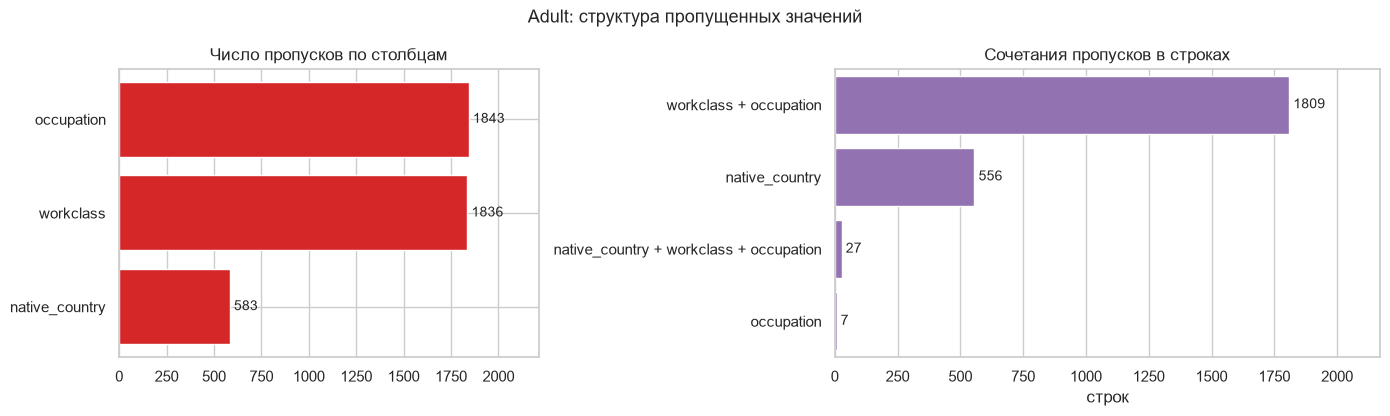

Значения workclass у строк, где пуст только occupation:
workclass
Never-worked    7


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1, 1.3]})

miss = missing[missing["пропусков"] > 0]["пропусков"].sort_values()
axes[0].barh(miss.index, miss.values, color="tab:red")
axes[0].bar_label(axes[0].containers[0], padding=3)
axes[0].set_title("Число пропусков по столбцам")
axes[0].set_xlim(0, miss.max() * 1.2)

# Совместная структура пропусков: в каких сочетаниях столбцы пусты одновременно
pattern = (adult_raw[miss.index].isna()
           .value_counts().rename("строк").reset_index())
pattern = pattern[pattern[miss.index].any(axis=1)]
pattern["шаблон пропусков"] = pattern[miss.index].apply(
    lambda r: " + ".join(c for c in miss.index if r[c]), axis=1)
sns.barplot(data=pattern, y="шаблон пропусков", x="строк", color="tab:purple", ax=axes[1])
axes[1].bar_label(axes[1].containers[0], padding=3)
axes[1].set_title("Сочетания пропусков в строках")
axes[1].set_ylabel("")
axes[1].set_xlim(0, pattern["строк"].max() * 1.2)

fig.suptitle("Adult: структура пропущенных значений", fontsize=13)
fig.tight_layout()
plt.show()

print("Значения workclass у строк, где пуст только occupation:")
print(adult_raw.loc[adult_raw["occupation"].isna() & adult_raw["workclass"].notna(), "workclass"]
      .value_counts().loc[lambda s: s > 0].to_string())

**Интерпретация.** Пропуски сосредоточены в трёх категориальных столбцах и затрагивают ≈ 7 %
строк. Важная закономерность: пропуски в `workclass` и `occupation` **почти всегда возникают
одновременно** (1836 строк), а 7 строк, где пуст только `occupation`, относятся к категории
*Never-worked* — профессии у них нет по определению. Следовательно, пропуск здесь не случаен,
а несёт смысл «вид занятости неизвестен / человек не работает».

**Выбранная стратегия обработки:**
* `workclass`, `occupation` — пропуск заменяется **отдельной категорией `Unknown`**: заполнение модой
  (`Private`, `Prof-specialty`) приписало бы ≈ 1800 людям, о работе которых ничего не известно,
  самую частую профессию и исказило бы её долю;
* `native_country` — заполнение **модой** (`United-States`): мода покрывает ≈ 91 % значений,
  пропусков всего 1.8 %, поэтому искажение распределения минимально.

Для сравнения оценим альтернативу — удаление строк с пропусками (`dropna`).

In [30]:
print(f"При удалении строк с пропусками (dropna) осталось бы {len(adult_raw.dropna())} строк "
      f"из {len(adult_raw)} — потеря {adult_raw.isna().any(axis=1).mean():.1%} данных")

adult_filled = adult_raw.copy()
for col in ["workclass", "occupation"]:
    adult_filled[col] = adult_filled[col].cat.add_categories("Unknown").fillna("Unknown")

country_mode = adult_filled["native_country"].mode()[0]
adult_filled["native_country"] = adult_filled["native_country"].fillna(country_mode)
print(f"native_country заполнен модой: {country_mode}")

print("\nПропусков после обработки:", int(adult_filled.isna().sum().sum()))

При удалении строк с пропусками (dropna) осталось бы 30162 строк из 32561 — потеря 7.4% данных
native_country заполнен модой: United-States

Пропусков после обработки: 0


### 2.3. Дубликаты

In [31]:
n_dups = adult_filled.duplicated().sum()
print(f"Полностью повторяющихся строк: {n_dups}")
display(adult_filled[adult_filled.duplicated(keep=False)]
        .sort_values(ADULT_COLUMNS).head(6))

adult = adult_filled.drop_duplicates().reset_index(drop=True)
print(f"Размерность до удаления дубликатов   : {adult_filled.shape}")
print(f"Размерность после удаления дубликатов: {adult.shape}")

Полностью повторяющихся строк: 24


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
17673,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
18698,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
6990,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
21318,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
15189,19,Private,146679,Some-college,10,Never-married,Exec-managerial,Own-child,Black,Male,0,0,30,United-States,<=50K
21490,19,Private,146679,Some-college,10,Never-married,Exec-managerial,Own-child,Black,Male,0,0,30,United-States,<=50K


Размерность до удаления дубликатов   : (32561, 15)
Размерность после удаления дубликатов: (32537, 15)


**Интерпретация.** Найдено **24 дубликата**. Они совпадают по всем 15 полям, включая
статистический вес `fnlwgt` (шестизначное число, уникальное для записи переписи), поэтому
это повторно внесённые записи, а не разные люди с одинаковыми характеристиками.
Дубликаты удалены; итоговый объём — **32537 строк**.

In [32]:
# Бинарная версия целевого признака — для корреляций и долей
adult["income_gt50k"] = (adult["income"] == ">50K").astype(int)
print(adult["income"].value_counts().to_string())

income
<=50K    24698
>50K      7839


## 3. Визуальный анализ распределений и поиск аномалий

### 3.1. Распределения числовых признаков

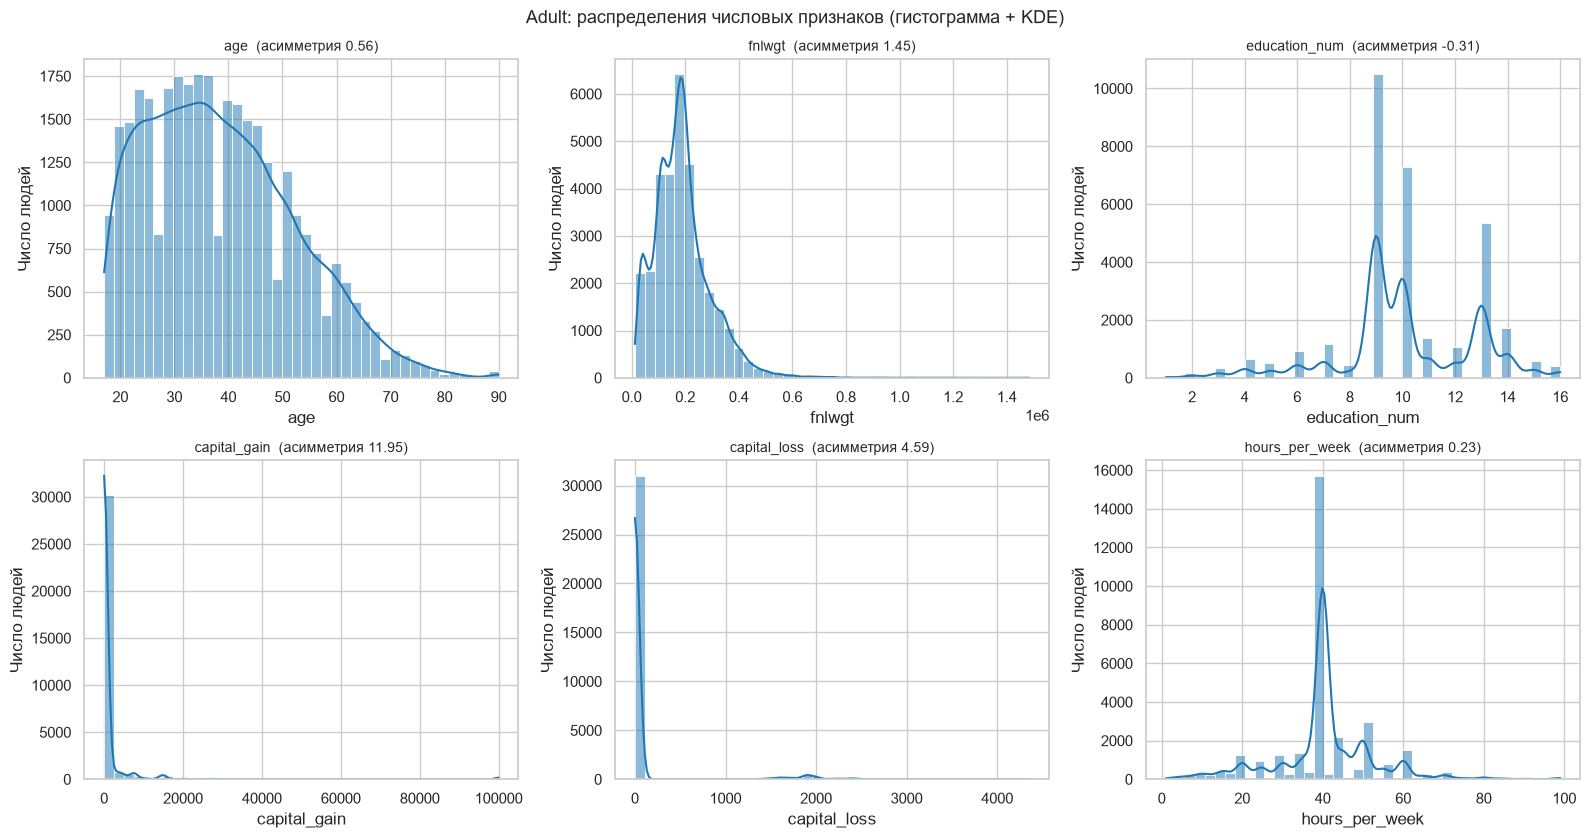

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))

for ax, col in zip(axes.flat, ADULT_NUM):
    sns.histplot(data=adult, x=col, bins=40, kde=True, color="tab:blue", ax=ax)
    ax.set_title(f"{col}  (асимметрия {adult[col].skew():.2f})", fontsize=10)
    ax.set_ylabel("Число людей")

fig.suptitle("Adult: распределения числовых признаков (гистограмма + KDE)", fontsize=13)
fig.tight_layout()
plt.show()

**Интерпретация.**
* `age` — правоскошенное распределение: основная масса — люди 20–50 лет, пожилых меньше.
* `education_num` — дискретный признак с пиками на уровнях 9 (HS-grad, школа), 10 (Some-college)
  и 13 (Bachelors).
* `hours_per_week` — резкий пик на значении **40** (стандартная рабочая неделя), остальные значения
  встречаются гораздо реже: это не непрерывное, а «округлённое» распределение.
* `capital_gain` и `capital_loss` — **вырожденные**: более 90 % нулей; на гистограмме видна
  одна высокая полоса у нуля и изолированные значения справа, в том числе пик в 99999.
* `fnlwgt` — правоскошенное распределение статистических весов.

Поскольку `capital_gain`/`capital_loss` почти всегда равны нулю, отдельно посмотрим на их ненулевую часть:

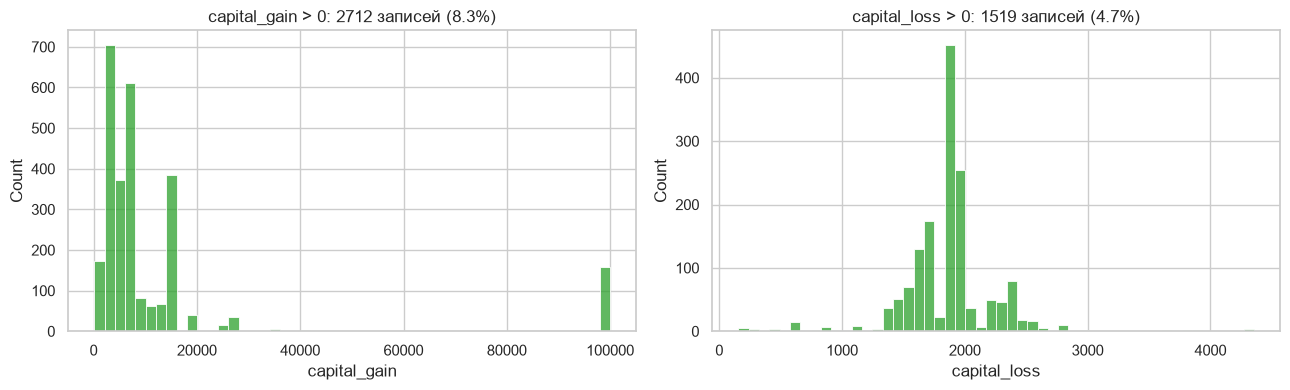

Записей с capital_gain = 99999: 159
Следующее по величине значение capital_gain: 41310


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ["capital_gain", "capital_loss"]):
    nonzero = adult.loc[adult[col] > 0, col]
    sns.histplot(nonzero, bins=50, color="tab:green", ax=ax)
    ax.set_title(f"{col} > 0: {len(nonzero)} записей ({len(nonzero) / len(adult):.1%})")
    ax.set_xlabel(col)
fig.tight_layout()
plt.show()

print("Записей с capital_gain = 99999:", int((adult["capital_gain"] == 99999).sum()))
print("Следующее по величине значение capital_gain:",
      int(adult.loc[adult["capital_gain"] < 99999, "capital_gain"].max()))

**Интерпретация.** Ненулевой `capital_gain` есть лишь у ≈ 8 % людей, `capital_loss` — у ≈ 5 %.
Значение **99999** отделено от остальных большим разрывом (следующее — 41310) и встречается
у 159 человек — это **искусственная отсечка** (максимальное кодируемое значение), а не реальная
сумма. Такие значения — настоящая аномалия данных; при моделировании признак лучше
бинаризовать («есть доход от капитала / нет») или логарифмировать.

### 3.2. Один признак — разные типы графиков

Сравним распределение возраста (`age`) у людей с доходом ≤50K и >50K четырьмя способами:
`histplot`, `kdeplot`, `violinplot` и `boxplot`.

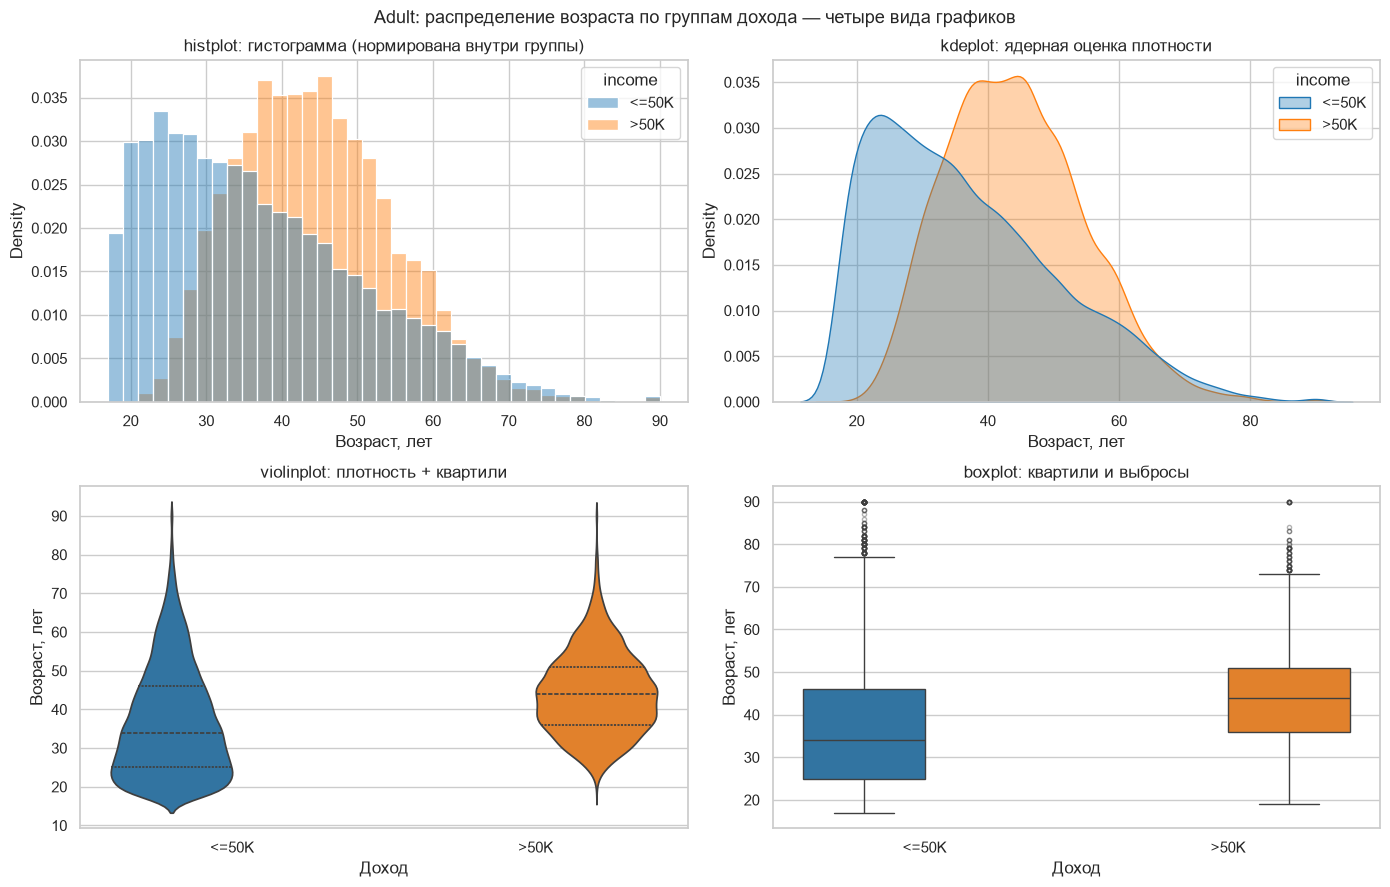

         mean    25%    50%    75%
income                            
<=50K  36.787 25.000 34.000 46.000
>50K   44.251 36.000 44.000 51.000


In [35]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
pal = {"<=50K": "tab:blue", ">50K": "tab:orange"}

sns.histplot(data=adult, x="age", hue="income", bins=37, multiple="layer", stat="density",
             common_norm=False, palette=pal, alpha=0.45, ax=axes[0, 0])
axes[0, 0].set_title("histplot: гистограмма (нормирована внутри группы)")

sns.kdeplot(data=adult, x="age", hue="income", fill=True, common_norm=False,
            palette=pal, alpha=0.35, ax=axes[0, 1])
axes[0, 1].set_title("kdeplot: ядерная оценка плотности")

sns.violinplot(data=adult, x="income", y="age", hue="income", inner="quartile",
               palette=pal, legend=False, ax=axes[1, 0])
axes[1, 0].set_title("violinplot: плотность + квартили")

sns.boxplot(data=adult, x="income", y="age", hue="income", palette=pal, legend=False,
            flierprops={"marker": "o", "markersize": 3, "alpha": 0.4}, ax=axes[1, 1])
axes[1, 1].set_title("boxplot: квартили и выбросы")

for ax in (axes[0, 0], axes[0, 1]):
    ax.set_xlabel("Возраст, лет")
for ax in (axes[1, 0], axes[1, 1]):
    ax.set_xlabel("Доход")
    ax.set_ylabel("Возраст, лет")
fig.suptitle("Adult: распределение возраста по группам дохода — четыре вида графиков", fontsize=13)
fig.tight_layout()
plt.show()

print(adult.groupby("income", observed=True)["age"].describe()[["mean", "25%", "50%", "75%"]])

**Интерпретация и сравнение типов графиков.** Люди с доходом >50K в среднем **старше**:
медиана 44 года против 34; распределение их возраста почти симметрично вокруг 40–50 лет,
а у группы ≤50K оно сильно скошено вправо — много молодых людей 18–30 лет, ещё не вышедших
на высокий доход.
* `histplot` и `kdeplot` лучше всего показывают **форму** распределения (асимметрию,
  положение пика); при этом гистограмма отражает «зубчатость» данных (возраст — целые числа),
  а KDE её сглаживает;
* `violinplot` сохраняет форму плотности и одновременно показывает квартили — удобен для
  компактного сравнения групп;
* `boxplot` формы не показывает, но единственный из четырёх явно отмечает **выбросы**
  (точки старше 77 лет у группы ≤50K и старше 73 лет у группы >50K).

### 3.3. Диаграммы размаха и статистические выбросы

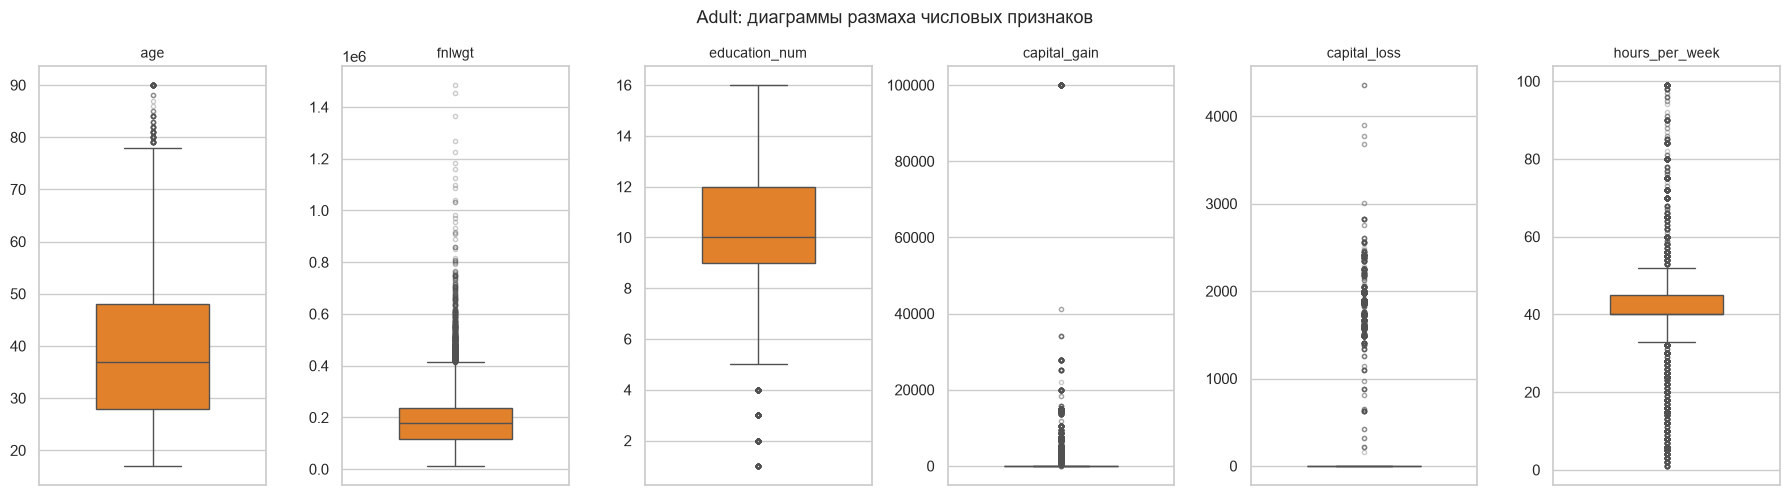

,нижняя граница,верхняя граница,выбросов,"доля, %"
hours_per_week,32.500,52.500,9002,27.670
capital_gain,0.000,0.000,2712,8.340
capital_loss,0.000,0.000,1519,4.670
education_num,4.500,16.500,1193,3.670
fnlwgt,-60922.000,415742.000,993,3.050
age,-2.000,78.000,142,0.440


In [36]:
fig, axes = plt.subplots(1, 6, figsize=(18, 5))
for ax, col in zip(axes, ADULT_NUM):
    sns.boxplot(y=adult[col], color="tab:orange", width=0.5,
                flierprops={"marker": "o", "markersize": 3, "alpha": 0.3}, ax=ax)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("")
fig.suptitle("Adult: диаграммы размаха числовых признаков", fontsize=13)
fig.tight_layout()
plt.show()

iqr_outliers(adult[ADULT_NUM])

**Интерпретация.** Правило 1.5·IQR нужно применять с учётом природы признака:
* `hours_per_week` формально содержит больше всего «выбросов» (≈ 28 %). Причина — экстремально
  узкий межквартильный размах (Q1 = 40, Q3 = 45): всё, что меньше 32.5 и больше 52.5 часов,
  считается выбросом. На деле частичная занятость и переработки — нормальное явление,
  это **не аномалии**;
* у `capital_gain` и `capital_loss` IQR = 0, поэтому **любое ненулевое значение** объявляется
  выбросом. Реальная аномалия здесь одна — отсечка 99999;
* у `age` выбросы — люди старше 78 лет (0.4 %): значения редкие, но корректные (максимум 90);
* у `education_num` выбросы — люди с образованием ниже 5 лет обучения (≈ 3.7 %): это малочисленные,
  но реальные категории (Preschool … 7th-8th);
* у `fnlwgt` ≈ 3 % выбросов — большие веса записей, что для статистического веса нормально.

Итог: удалять выбросы механически по IQR в этом наборе **нельзя** — пострадали бы целые
содержательные группы людей.

### 3.4. Категориальные признаки

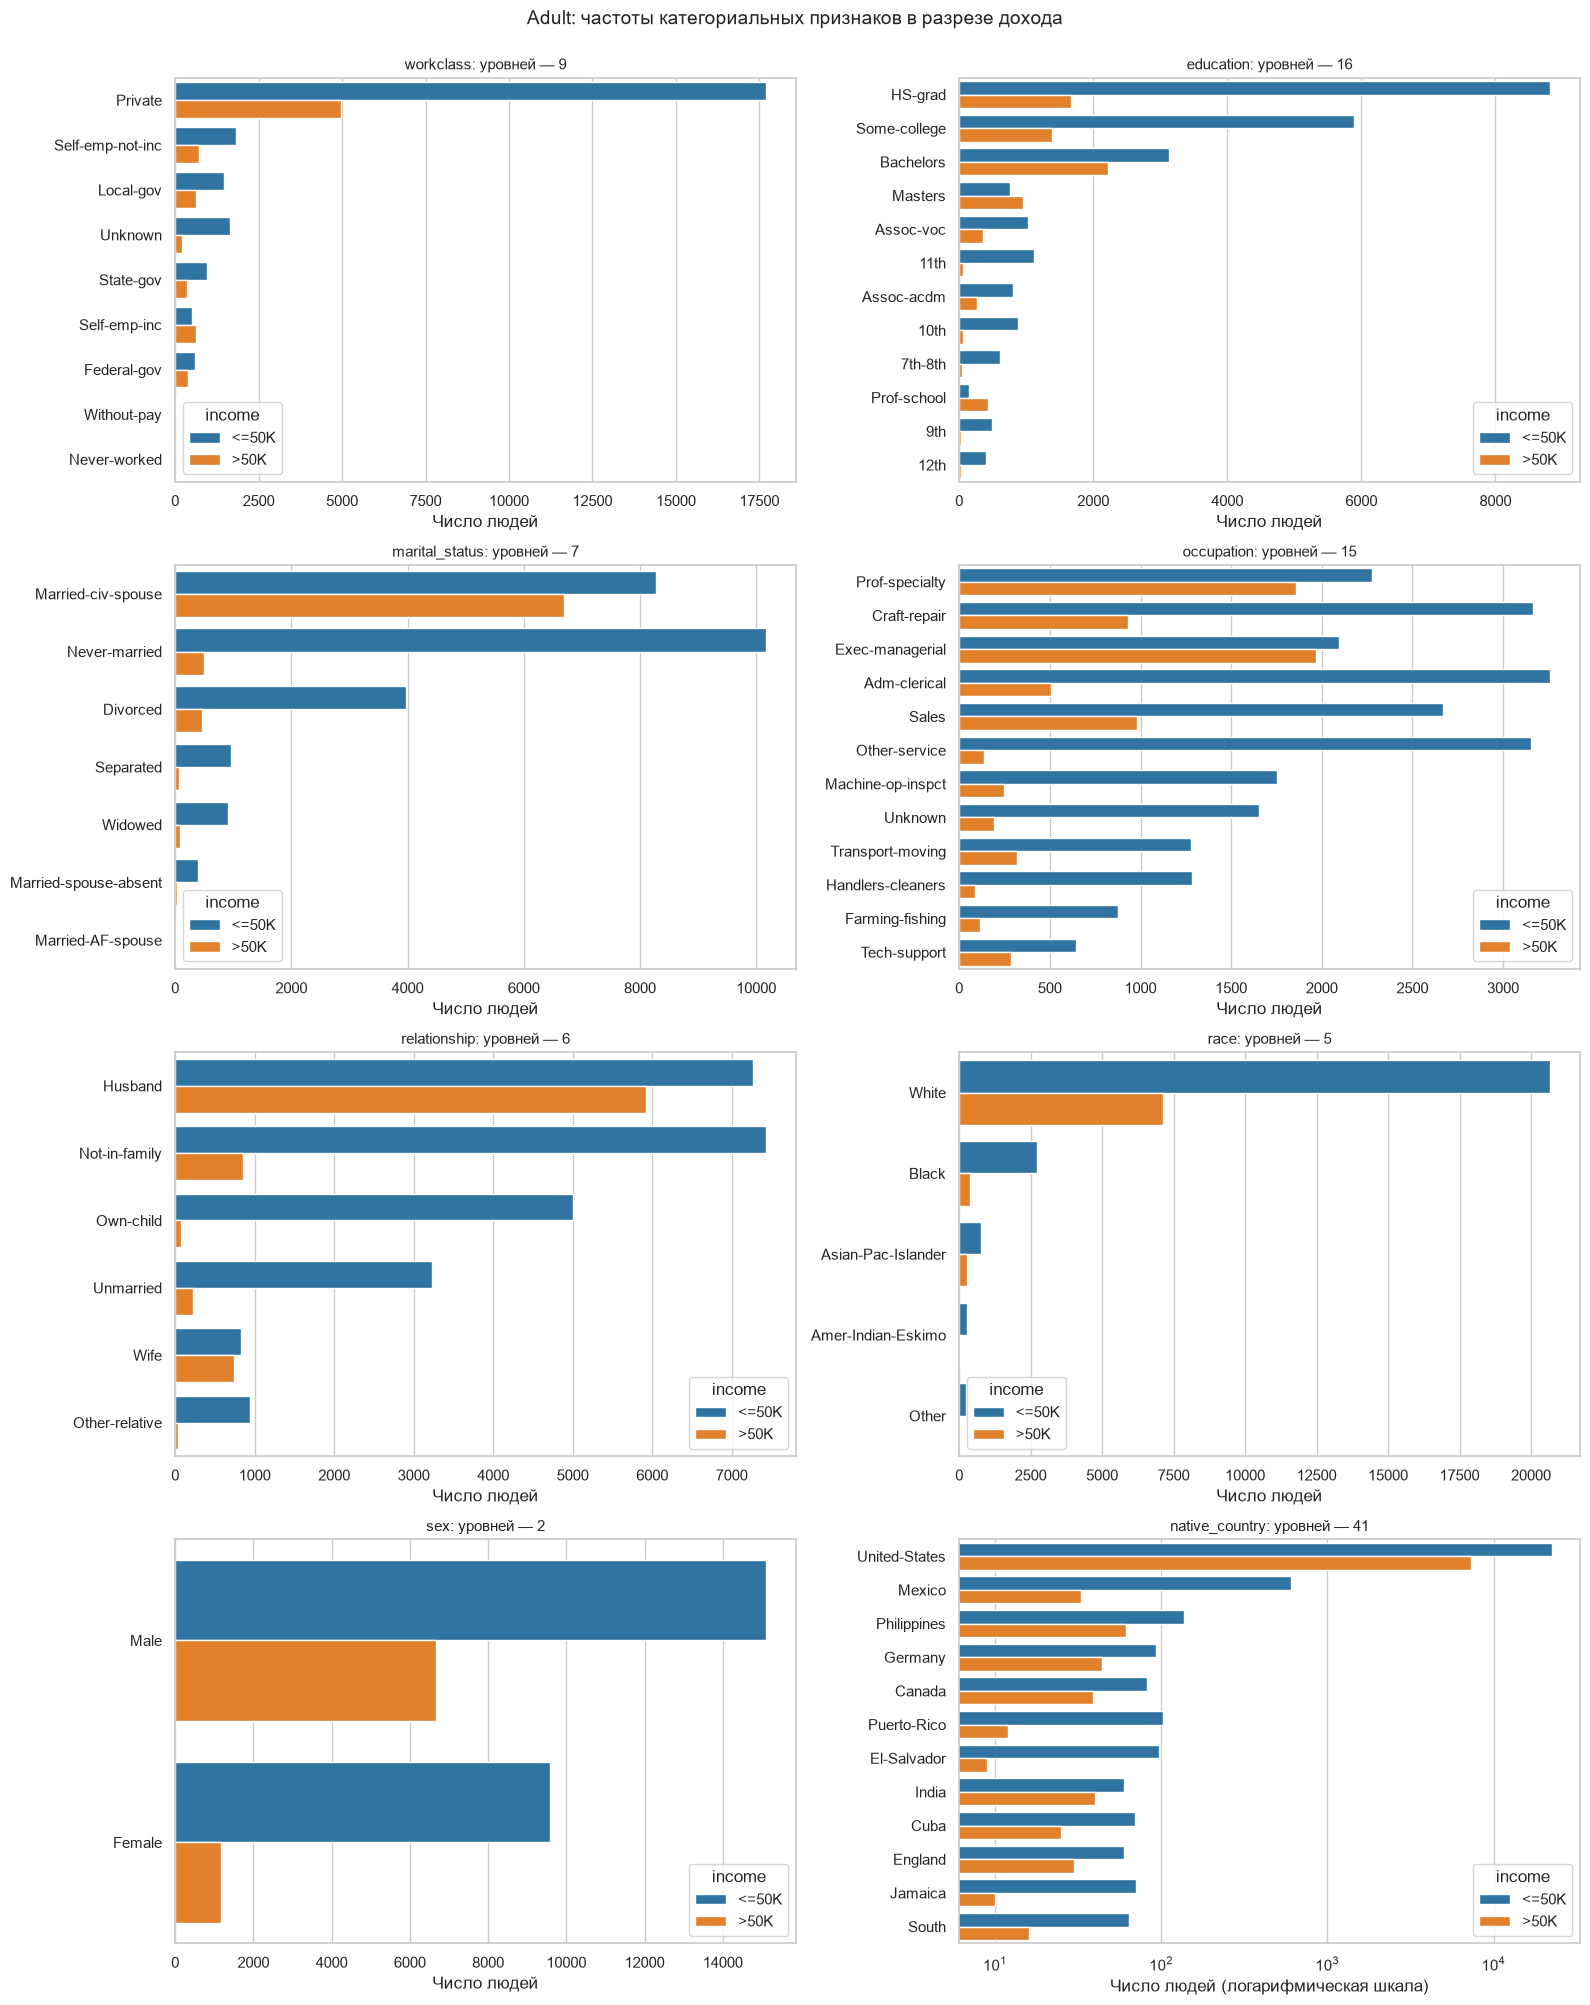

In [37]:
cat_plot = ["workclass", "education", "marital_status", "occupation",
            "relationship", "race", "sex", "native_country"]

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
for ax, col in zip(axes.flat, cat_plot):
    counts = adult[col].value_counts()
    if len(counts) > 12:  # для признаков с большим числом уровней — топ-12
        counts = counts.head(12)
    order = counts.index
    sns.countplot(data=adult[adult[col].isin(order)], y=col, hue="income", order=order,
                  palette={"<=50K": "tab:blue", ">50K": "tab:orange"}, ax=ax)
    ax.set_title(f"{col}: уровней — {adult[col].nunique()}", fontsize=11)
    ax.set_xlabel("Число людей")
    ax.set_ylabel("")
    if col == "native_country":
        ax.set_xscale("log")
        ax.set_xlabel("Число людей (логарифмическая шкала)")

fig.suptitle("Adult: частоты категориальных признаков в разрезе дохода", fontsize=14, y=1.0)
fig.tight_layout()
plt.show()

**Интерпретация.** Частоты категорий сильно неравномерны: в каждом признаке есть
доминирующий уровень и «хвост» редких уровней (например, в `native_country` после США
следующая страна — Мексика — даёт лишь ≈ 2 % записей; шкала логарифмическая).
Редкие уровни при кодировании стоит объединять в группу «Other».
Уже по абсолютным частотам видно, что доля высокого дохода резко различается между
категориями — посмотрим на неё напрямую.

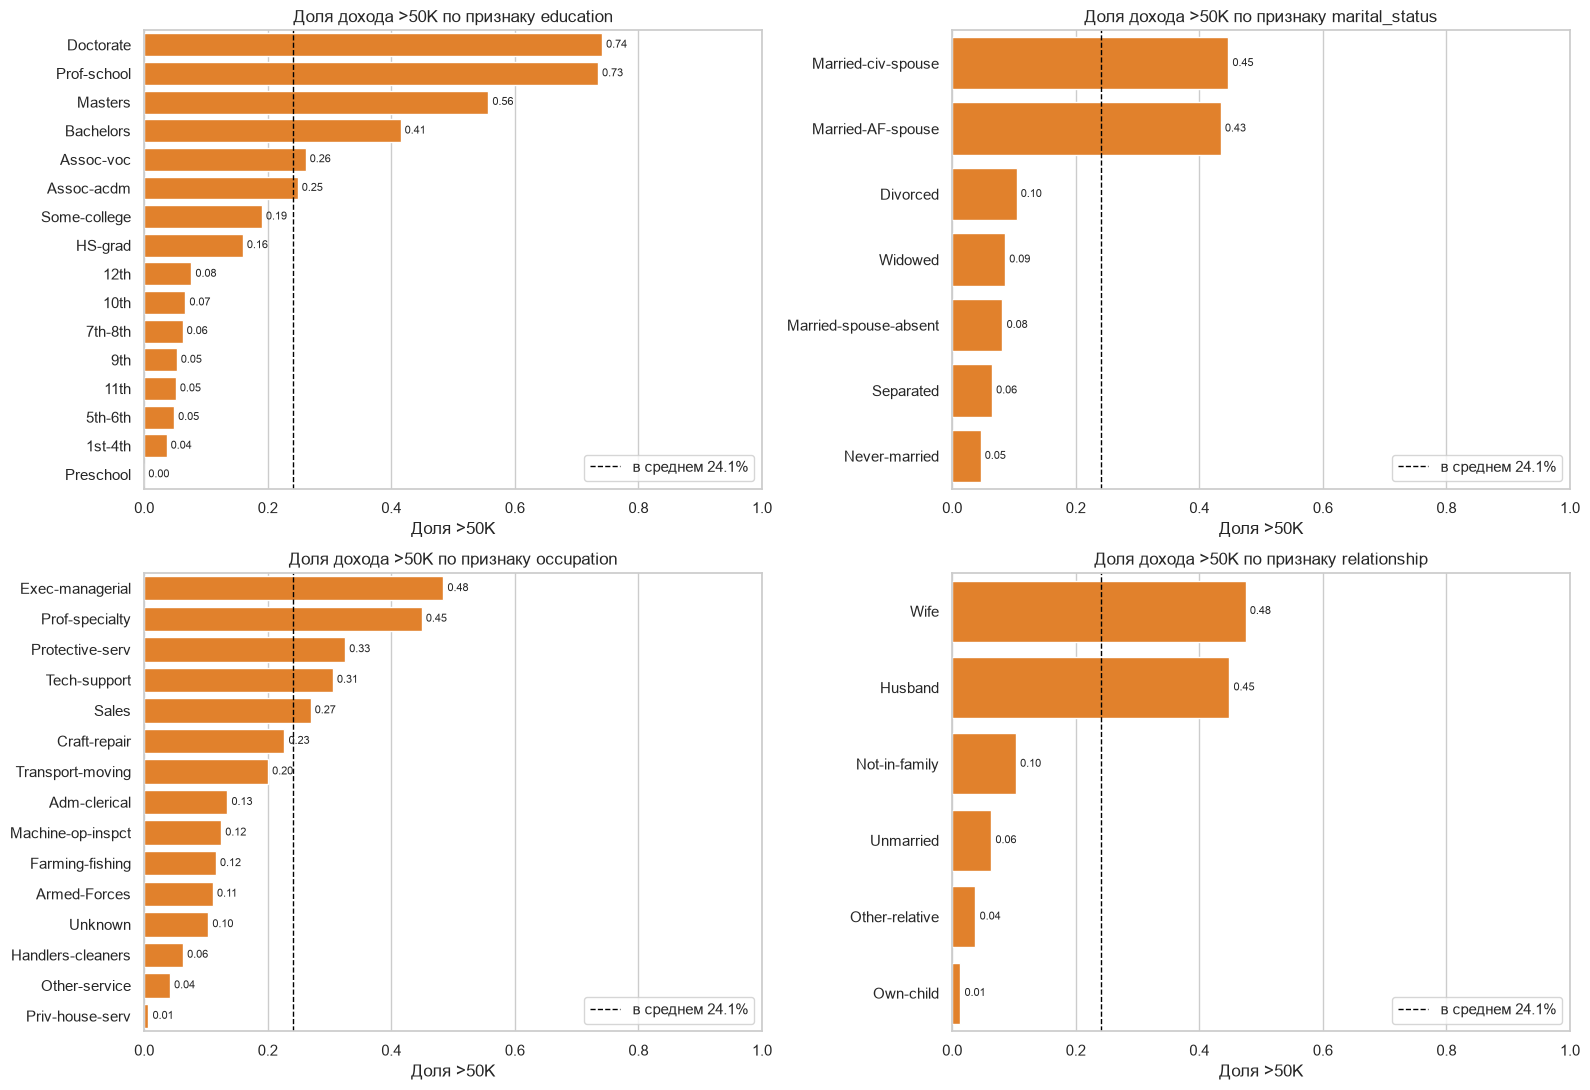

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
overall = adult["income_gt50k"].mean()

for ax, col in zip(axes.flat, ["education", "marital_status", "occupation", "relationship"]):
    share = (adult.groupby(col, observed=True)["income_gt50k"].mean()
             .sort_values(ascending=False))
    sns.barplot(x=share.values, y=share.index.astype(str), color="tab:orange", ax=ax)
    ax.axvline(overall, color="black", ls="--", lw=1, label=f"в среднем {overall:.1%}")
    ax.bar_label(ax.containers[0], fmt="%.2f", padding=3, fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_title(f"Доля дохода >50K по признаку {col}")
    ax.set_xlabel("Доля >50K")
    ax.set_ylabel("")
    ax.legend(loc="lower right")

fig.tight_layout()
plt.show()

**Интерпретация.**
* **Образование** — сильнейший фактор: доля высокого дохода растёт почти монотонно с уровнем
  образования — от нуля у Preschool до ≈ 73–74 % у Doctorate и Prof-school.
* **Семейное положение / роль в семье:** у состоящих в браке (Married-civ-spouse, Husband, Wife)
  доля >50K ≈ 45–48 %, тогда как у никогда не состоявших в браке и у живущих с родителями
  (Own-child) — единицы процентов.
* **Профессия:** лидируют управленческие (Exec-managerial) и интеллектуальные профессии
  (Prof-specialty) — ≈ 45–48 %, минимальна доля у Priv-house-serv и Other-service.
  Группа `Unknown`, созданная при обработке пропусков, имеет низкую долю высокого дохода (≈ 10 %),
  что подтверждает её смысл «не работает / занятость не указана».

## 4. Корреляционный анализ и зависимости

### 4.1. Матрица корреляции числовых признаков

В матрицу дополнительно включены бинарные признаки `income_gt50k` (доход >50K) и `sex_male`,
чтобы оценить их линейную связь с числовыми признаками.

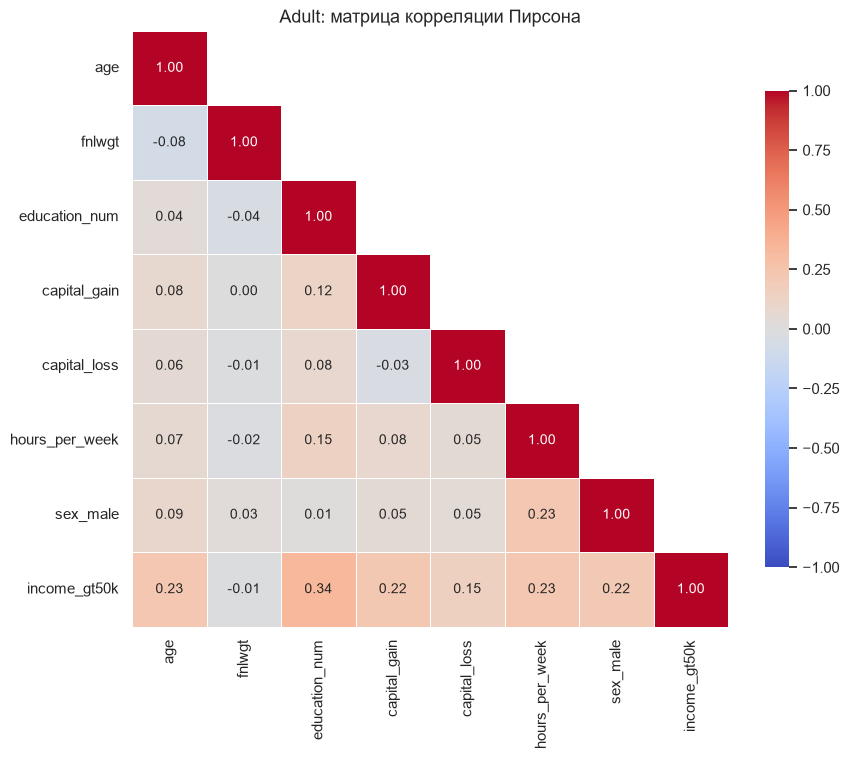

r Пирсона
education_num  income_gt50k        0.335
age            income_gt50k        0.234
hours_per_week income_gt50k        0.230
               sex_male            0.229
capital_gain   income_gt50k        0.223
sex_male       income_gt50k        0.216
capital_loss   income_gt50k        0.151
education_num  hours_per_week      0.148

In [39]:
adult_num = adult[ADULT_NUM].copy()
adult_num["sex_male"] = (adult["sex"] == "Male").astype(int)
adult_num["income_gt50k"] = adult["income_gt50k"]

adult_corr = adult_num.corr(method="pearson")

fig, ax = plt.subplots(figsize=(9, 7.5))
mask = np.triu(np.ones_like(adult_corr, dtype=bool), k=1)
sns.heatmap(adult_corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Adult: матрица корреляции Пирсона", fontsize=13)
ax.grid(False)
fig.tight_layout()
plt.show()

top_correlations(adult_corr, n=8).rename("r Пирсона").to_frame()

**Интерпретация.** Линейные связи между числовыми признаками Adult **слабые**: максимальный
коэффициент ≈ 0.34 (`education_num` ↔ `income_gt50k`). Далее идут `age`, `hours_per_week`,
`capital_gain` и пол — все они положительно связаны с высоким доходом (r ≈ 0.22–0.23).
`fnlwgt` ни с чем не коррелирует (|r| < 0.08), что подтверждает: это технический вес, а не
характеристика человека. Отсутствие сильных корреляций между числовыми признаками означает,
что мультиколлинеарности нет, но и простая линейная зависимость дохода от одного признака
отсутствует.

### 4.2. Связи категориальных признаков (V Крамера)

Коэффициент Пирсона неприменим к номинальным признакам, поэтому для них построена матрица
**V Крамера** на основе статистики χ² таблицы сопряжённости: 0 — независимость, 1 — полная связь.

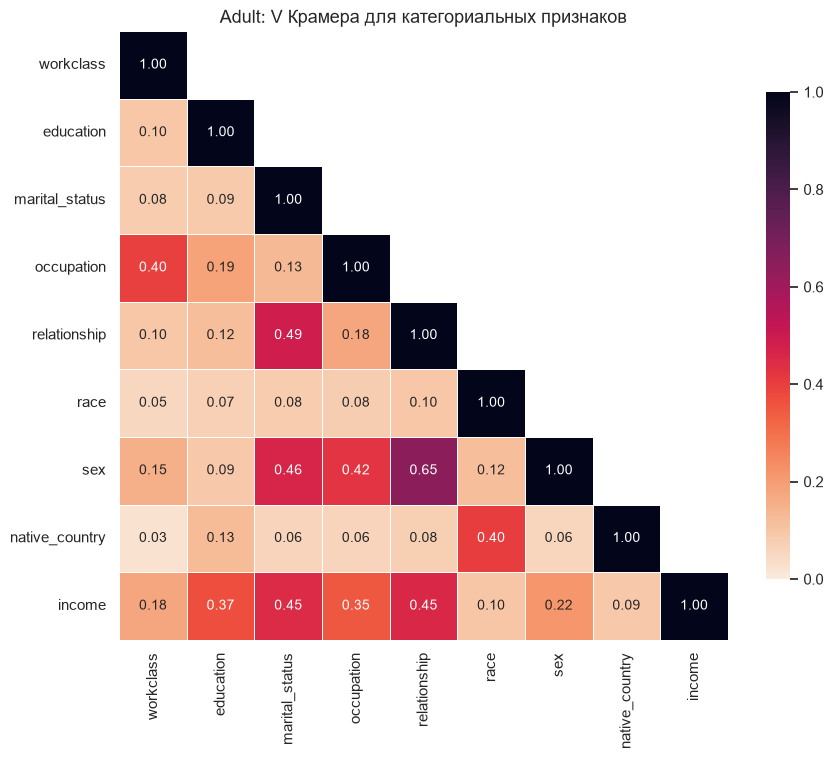

V Крамера
relationship   sex               0.649
marital_status relationship      0.488
               sex               0.462
relationship   income            0.453
marital_status income            0.447
occupation     sex               0.424

In [40]:
def cramers_v(x: pd.Series, y: pd.Series) -> float:
    # V Крамера с поправкой на смещение (Bergsma, 2013)
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    r, k = table.shape
    phi2 = max(0.0, chi2 / n - (k - 1) * (r - 1) / (n - 1))
    r_c, k_c = r - (r - 1) ** 2 / (n - 1), k - (k - 1) ** 2 / (n - 1)
    return float(np.sqrt(phi2 / min(k_c - 1, r_c - 1)))


cat_cols = ADULT_CAT
cv = pd.DataFrame(np.eye(len(cat_cols)), index=cat_cols, columns=cat_cols)
for i, a in enumerate(cat_cols):
    for b in cat_cols[i + 1:]:
        cv.loc[a, b] = cv.loc[b, a] = cramers_v(adult[a], adult[b])

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(cv, mask=np.triu(np.ones_like(cv, dtype=bool), k=1), annot=True, fmt=".2f",
            cmap="rocket_r", vmin=0, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Adult: V Крамера для категориальных признаков", fontsize=13)
ax.grid(False)
fig.tight_layout()
plt.show()

top_correlations(cv, n=6).rename("V Крамера").to_frame()

**Интерпретация.** Среди категориальных признаков есть **сильные зависимости**, которые
матрица Пирсона не показывает:
* `relationship` ↔ `sex` (V ≈ 0.65) и `relationship` ↔ `marital_status` (V ≈ 0.49): уровни
  `Husband`/`Wife` однозначно определяют пол и семейное положение — признаки частично
  **дублируют** друг друга;
* `occupation` ↔ `sex` (V ≈ 0.42) — профессии заметно различаются по половому составу;
* `workclass` ↔ `occupation` (V ≈ 0.40) — в первую очередь за счёт общей категории `Unknown`;
* `race` ↔ `native_country` (V ≈ 0.40) — ожидаемая связь происхождения и расы;
* с целевым `income` сильнее всего связаны `relationship` и `marital_status` (V ≈ 0.45).

### 4.3. Диаграммы рассеяния и парные графики

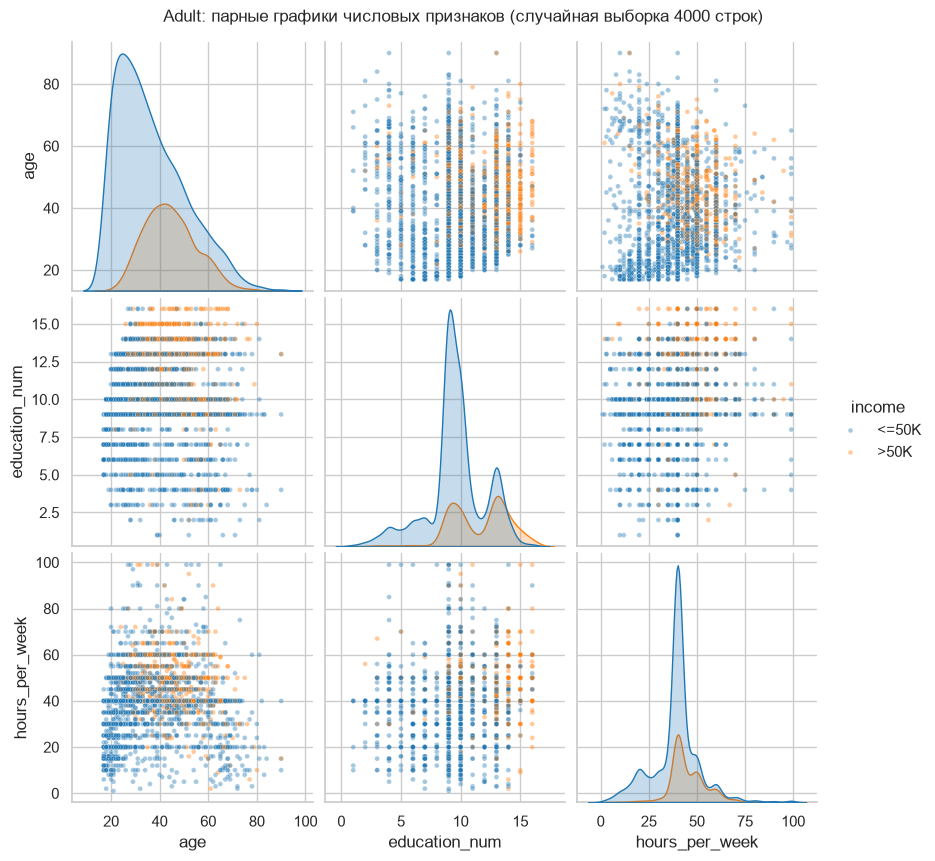

In [41]:
sample = adult.sample(4000, random_state=42)

g = sns.pairplot(sample, vars=["age", "education_num", "hours_per_week"], hue="income",
                 palette={"<=50K": "tab:blue", ">50K": "tab:orange"}, diag_kind="kde",
                 height=2.8, plot_kws={"s": 12, "alpha": 0.4})
g.figure.suptitle("Adult: парные графики числовых признаков (случайная выборка 4000 строк)",
                  y=1.02, fontsize=12)
plt.show()

**Интерпретация.** Для наглядности использована случайная подвыборка 4000 строк (на 32 тыс.
точек график перегружен). Облака точек не вытянуты вдоль прямых — линейной связи между
`age`, `education_num` и `hours_per_week` действительно нет. Однако точки класса >50K
сосредоточены в области **education_num ≥ 13**, возраста 35–60 лет и рабочей недели
**≥ 40 часов**; на диагональных KDE распределения обоих классов заметно сдвинуты.
Дискретность `education_num` и пик `hours_per_week` = 40 проявляются как горизонтальные
и вертикальные «полосы» точек.

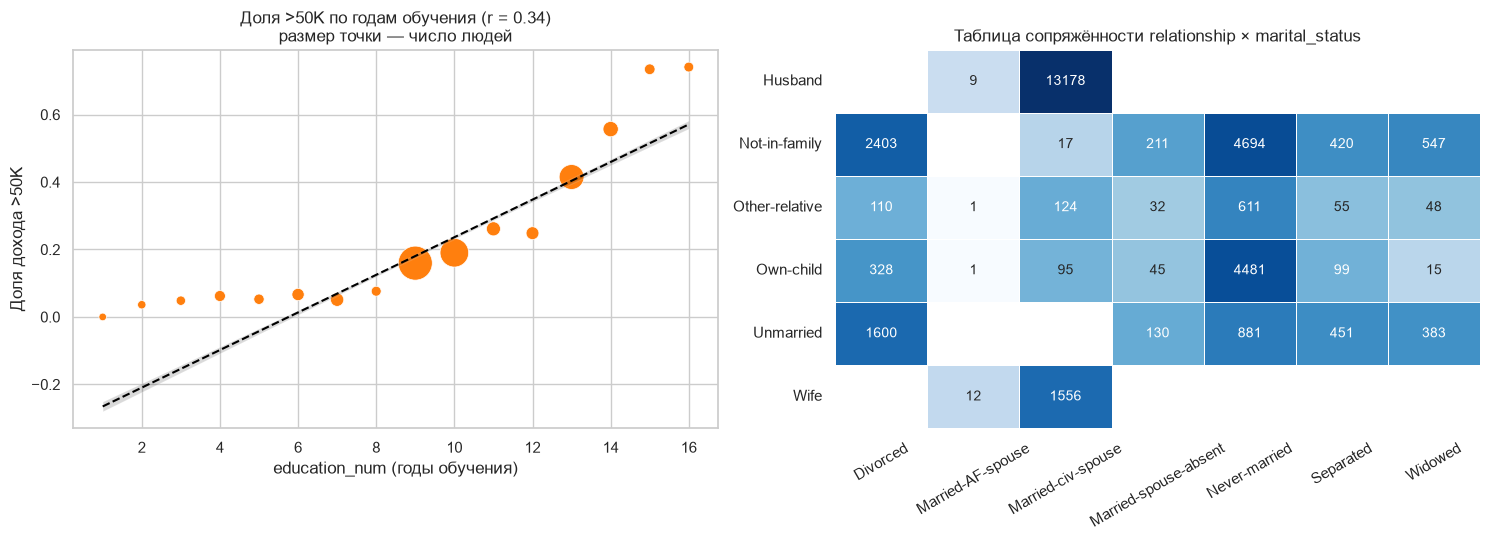

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Пара с наибольшей связью с целевым признаком: education_num ↔ доход
edu_share = adult.groupby("education_num")["income_gt50k"].agg(["mean", "size"]).reset_index()
sns.scatterplot(data=edu_share, x="education_num", y="mean", size="size", sizes=(30, 600),
                color="tab:orange", legend=False, ax=axes[0])
sns.regplot(data=adult, x="education_num", y="income_gt50k", scatter=False,
            color="black", line_kws={"ls": "--", "lw": 1.5}, ax=axes[0])
axes[0].set_title(f"Доля >50K по годам обучения (r = {adult_corr.loc['education_num', 'income_gt50k']:.2f})\n"
                  "размер точки — число людей")
axes[0].set_xlabel("education_num (годы обучения)")
axes[0].set_ylabel("Доля дохода >50K")

# Самая сильная связь категориальных признаков: relationship ↔ marital_status
ct = pd.crosstab(adult["relationship"], adult["marital_status"])
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", norm=matplotlib.colors.LogNorm(),
            cbar=False, linewidths=0.5, ax=axes[1])
axes[1].grid(False)
axes[1].set_title("Таблица сопряжённости relationship × marital_status")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=30)

fig.tight_layout()
plt.show()

**Интерпретация.** Слева: доля людей с высоким доходом почти монотонно растёт с числом лет
обучения — от 0–8 % при 1–8 годах до ≈ 74 % у докторов наук; рост ускоряется после 13 лет
(бакалавриат). Связь сильная, но **нелинейная**: прямая линейной регрессии (пунктир)
плохо описывает точки и при малом числе лет обучения даже уходит в отрицательные доли,
поэтому коэффициент Пирсона (≈ 0.34) силу связи недооценивает. Справа: таблица сопряжённости показывает природу дублирования
категориальных признаков — все `Husband` и `Wife` относятся к состоящим в браке
(`Married-civ-spouse`/`Married-AF-spouse`), а `Not-in-family`, `Own-child`, `Unmarried`
почти полностью приходятся на остальные статусы.

## Вывод по набору Adult

* **Структура:** 32561 строка × 15 столбцов (6 числовых, 9 категориальных). «Сырой» файл
  требует корректного чтения: ведущие пробелы в значениях и пропуски, закодированные
  символом `?`. Признак `education_num` дублирует `education`, `fnlwgt` — технический вес записи.
* **Очистка:** пропуски в `workclass`, `occupation` (≈ 5.7 %, возникают совместно)
  заменены категорией `Unknown`, в `native_country` (1.8 %) — модой; удалены **24 дубликата**.
  Итоговый объём — 32537 строк.
* **Аномалии:** формально по IQR выбросов много (особенно в `hours_per_week`, `capital_gain`,
  `capital_loss`), но в основном это следствие узкого межквартильного размаха и нулевой
  медианы. Реальная аномалия — искусственная отсечка `capital_gain` = 99999 (159 записей).
* **Корреляции:** между числовыми признаками линейные связи слабые (|r| ≤ 0.34);
  сильнее всего с доходом связаны образование, возраст, часы работы и пол. Среди категориальных
  признаков есть сильные связи (`relationship` ↔ `sex`/`marital_status`, V Крамера до 0.65),
  а доход сильнее всего зависит от семейного положения и уровня образования.
  Классы целевого признака несбалансированы (≈ 76 % / 24 %).

---
# Часть 3. Дополнительное задание — интерактивный дашборд Streamlit

Ключевые элементы анализа и очистки набора **Adult** перенесены в веб-приложение
[`app_streamlit.py`](app_streamlit.py). Возможности приложения:

* **очистка данных в боковой панели**: выбор способа обработки пропусков (категория `Unknown` /
  заполнение модой / удаление строк) и флаг удаления дубликатов; сводка до/после;
* **фильтры**: диапазон возраста и часов работы в неделю, пол, класс дохода, вид занятости,
  уровень образования;
* **вкладки**:
  * «Данные» — динамическая таблица отфильтрованных строк, размерность, `info`-сводка по типам,
    пропускам и числу уникальных значений;
  * «Статистика» — описательные статистики числовых и категориальных признаков;
  * «Распределения» — выбор признака и типа графика (гистограмма, KDE, violin, boxplot) с
    разбиением по доходу, а также таблица выбросов по правилу IQR;
  * «Категории» — частоты и доля дохода >50K по выбранному категориальному признаку;
  * «Корреляции» — тепловая карта Пирсона и диаграмма рассеяния для выбранной пары признаков.

**Запуск** (в окружении, где установлен `streamlit`):

```bat
conda activate lab1_terminal
conda install streamlit -y
cd lab02
streamlit run app_streamlit.py
```

Пакет `streamlit` установлен в окружение `lab1_terminal` через терминал командой `conda install`;
протокол установки — [`logs/conda_install_streamlit.log`](logs/conda_install_streamlit.log).
Приложение открывается в браузере по адресу <http://localhost:8501>.

![Дашборд: вкладка «Данные» — таблица, метрики очистки и фильтры](images/01_streamlit_data.png)

![Дашборд: вкладка «Распределения» — выбор признака и типа графика, таблица выбросов](images/02_streamlit_distributions.png)

![Дашборд: вкладка «Категории» — частоты и доля дохода >50K по уровням признака](images/03_streamlit_categories.png)

![Дашборд: вкладка «Корреляции» — тепловая карта и диаграмма рассеяния](images/04_streamlit_correlations.png)

---
# Итоговые выводы

1. Для работы подобраны **два новых набора данных** из репозитория UCI: числовой
   **Wine Quality** (1599 × 12) и смешанный **Adult** (32561 × 15, 9 категориальных признаков).
2. Для каждого набора выполнен **первичный аудит**: просмотр первых и последних строк,
   размерность, `.info()` и проверка соответствия типов значениям. В Wine целевой `quality` по
   смыслу порядковый категориальный; в Adult найдены скрытые пропуски `?`, ведущие пробелы
   и дублирующий признак `education_num`.
3. Получены **описательные статистики** числовых (среднее, медиана, СКО, квантили, асимметрия)
   и категориальных (число уникальных значений, мода, её частота) признаков.
   **Пропуски** обработаны в Adult двумя способами (новая категория и мода) с обоснованием
   выбора; **дубликаты** найдены и удалены в обоих наборах (240 и 24 строки).
4. Распределения визуализированы гистограммами, KDE, скрипичными диаграммами, ECDF и
   boxplot; на примерах `alcohol` и `age` **сравнены разные типы графиков** для одной задачи.
   Выбросы найдены по правилу IQR и **проинтерпретированы**: в Wine это редкие, но реальные
   образцы (рекомендуется логарифмирование), в Adult большая часть «выбросов» — артефакт
   узкого IQR, а реальная аномалия — отсечка `capital_gain` = 99999.
5. **Корреляционный анализ:** в Wine выявлена группа умеренно связанных кислотных признаков
   (|r| до 0.69) и главные факторы качества — `alcohol` и `volatile_acidity`; в Adult линейные
   связи слабые, а сильные зависимости проявляются между категориальными признаками
   (V Крамера) и в нелинейной связи образования с доходом.
6. В качестве дополнительного задания разработан **интерактивный дашборд Streamlit**
   для набора Adult с фильтрами, выбором способа очистки, типа графиков и динамическими таблицами.